(mmm_roas_parametrization)=
# Custom MMM with ROAS Parameterization

This notebook demonstrates how to build a custom Media Mix Model (MMM) parameterized by **ROAS (Return on Ad Spend)** instead of the classical regression (beta) coefficients. The technique is based on the paper [Media Mix Model Calibration With Bayesian Priors](https://research.google/pubs/media-mix-model-calibration-with-bayesian-priors/) by Zhang et al. (2024) and the simulation study [Media Mix Model and Experimental Calibration](https://juanitorduz.github.io/mmm_roas/) by [Juan Orduz](https://juanitorduz.github.io/).

## Motivation

In practice, MMMs suffer from omitted variable bias (unobserved confounders) which leads to biased channel contribution and ROAS estimates. Running randomized experiments (lift tests) can provide unbiased ROAS estimates for individual channels. The key idea in this notebook is to **reparameterize** the model so that the channel scaling coefficient $\beta$ is expressed in terms of ROAS:

$$
\beta_m = \frac{\text{ROAS}_m \cdot \sum_t x_{m,t}}{\sum_t f_m(x_{m,t})}
$$

where $x_{m,t}$ is the raw spend for channel $m$ at time $t$, and $f_m$ is the adstock + saturation transformation. This allows injecting experimental ROAS estimates directly as Bayesian priors, partially correcting for confounding bias.

This is a different approach to the one taken in {ref}`mmm_roas`, where the ROAS is not a parameter of the model, but a derived quantity from the beta coefficients after lift-test calibration using the saturation-curve method (see {ref}`mmm_lift_test`). The benefit of PyMC-Marketing's calibration method is that the more experiments are conducted, the more precise the ROAS estimates become. In contrast, the approach here is more "static" in the sense that it uses an aggregation (e.g. mean or median) of ROAS estimates from experiments. We are losing information this way. Nevertheless, it is a clever and convenient parametrization that also works well in practice 🙂. The purpose of this notebook is to illustrate how PyMC-Marketing's components can be used to build custom models, and how the ROAS parameterization works.

## Approach

We consider the same example as in the case study {ref}`mmm_roas`, where we have one unobserved confounder $z$ that affects both channel $x_1$ spend and the target $y$. In this notebook, we compare two custom PyMC models:

1. **Baseline model** (`model_baseline`): Standard beta-coefficient priors, no confounder $z$ in the model. This demonstrates the bias from omitted variables.
2. **Calibrated model** (`model_calibrated`): ROAS priors from "experiments" replace beta priors. Same structure, still no $z$, but ROAS priors mitigate the bias.

We use [PyMC-Marketing](https://github.com/pymc-labs/pymc-marketing) components (`GeometricAdstock`, `YearlyFourier`) alongside raw PyMC for maximum flexibility.

```{seealso}
- {ref}`mmm_roas` for the full 3-model comparison using lift-test calibration.
- {ref}`mmm_components` and {ref}`mmm_custom_splines` for other custom model examples.
- {ref}`mmm_lift_test` for the lift-test likelihood approach to calibration.
```

## Prepare Notebook

In [1]:
import arviz as az
import arviz_plots as azp
import graphviz as gr
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pymc.dims as pmd
import pytensor.xtensor as ptx
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior
from sklearn.preprocessing import MaxAbsScaler
from xarray import DataArray

from pymc_marketing.mmm import GeometricAdstock
from pymc_marketing.mmm.fourier import YearlyFourier
from pymc_marketing.mmm.transformers import logistic_saturation
from pymc_marketing.paths import data_dir

az.style.use("arviz-vibrant")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Load and Explore Data

We use the same synthetic dataset from {ref}`mmm_roas`. It was generated with an unobserved confounder $z$ that causally affects both channel $x_1$ spend and the target $y$ (for more details on the data generating process, see the original blog post [Media Mix Modeling with PyMC-Marketing](https://juanitorduz.github.io/mmm_roas/)). The dataset includes ground-truth columns (`y01` and `y02`) representing potential outcomes when each channel is turned off, which we use to compute the true ROAS.

In [3]:
data_path = data_dir / "mmm_roas_data.csv"
raw_df = pd.read_csv(data_path, parse_dates=["date"])
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  131 non-null    datetime64[ns]
 1   dayofyear             131 non-null    int64         
 2   quarter               131 non-null    object        
 3   trend                 131 non-null    float64       
 4   cs                    131 non-null    float64       
 5   cc                    131 non-null    float64       
 6   seasonality           131 non-null    float64       
 7   z                     131 non-null    float64       
 8   x1                    131 non-null    float64       
 9   x2                    131 non-null    float64       
 10  epsilon               131 non-null    float64       
 11  x1_adstock            131 non-null    float64       
 12  x2_adstock            131 non-null    float64       
 13  x1_adstock_saturated

### Causal DAG

The data generating process follows this causal structure. Note the confounder $z$ affecting both $x_1$ and $y$:

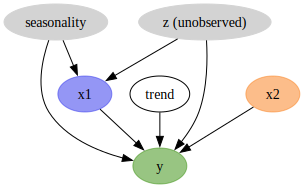

In [4]:
g = gr.Digraph()
g.node(name="seasonality", label="seasonality", color="lightgray", style="filled")
g.node(name="trend", label="trend")
g.node(name="z", label="z (unobserved)", color="lightgray", style="filled")
g.node(name="x1", label="x1", color="#2a2eec80", style="filled")
g.node(name="x2", label="x2", color="#fa7c1780", style="filled")
g.node(name="y", label="y", color="#328c0680", style="filled")
g.edge(tail_name="seasonality", head_name="x1")
g.edge(tail_name="z", head_name="x1")
g.edge(tail_name="x1", head_name="y")
g.edge(tail_name="seasonality", head_name="y")
g.edge(tail_name="trend", head_name="y")
g.edge(tail_name="z", head_name="y")
g.edge(tail_name="x2", head_name="y")
g

Since $z$ is unobserved, we cannot include it in the model. This means the backdoor path $x_1 \leftarrow z \rightarrow y$ remains open, leading to omitted variable bias in the estimate of $x_1$'s effect.

### Select Modeling Columns

For modeling, we only use `date`, `dayofyear`, `x1`, `x2`, and `y`, deliberately excluding $z$ to simulate a realistic scenario.

In [5]:
channels = ["x1", "x2"]
target = "y"
model_df = raw_df.filter(["date", "dayofyear", *channels, target])
model_df.head()

,date,dayofyear,x1,x2,y
0,2021-10-02,275,0.646554,0.336188,199.329637
1,2021-10-09,282,1.411917,0.203931,371.237041
2,2021-10-16,289,0.837610,0.024026,272.215933
3,2021-10-23,296,0.973612,0.120257,291.104040
4,2021-10-30,303,1.415985,0.084630,386.243000


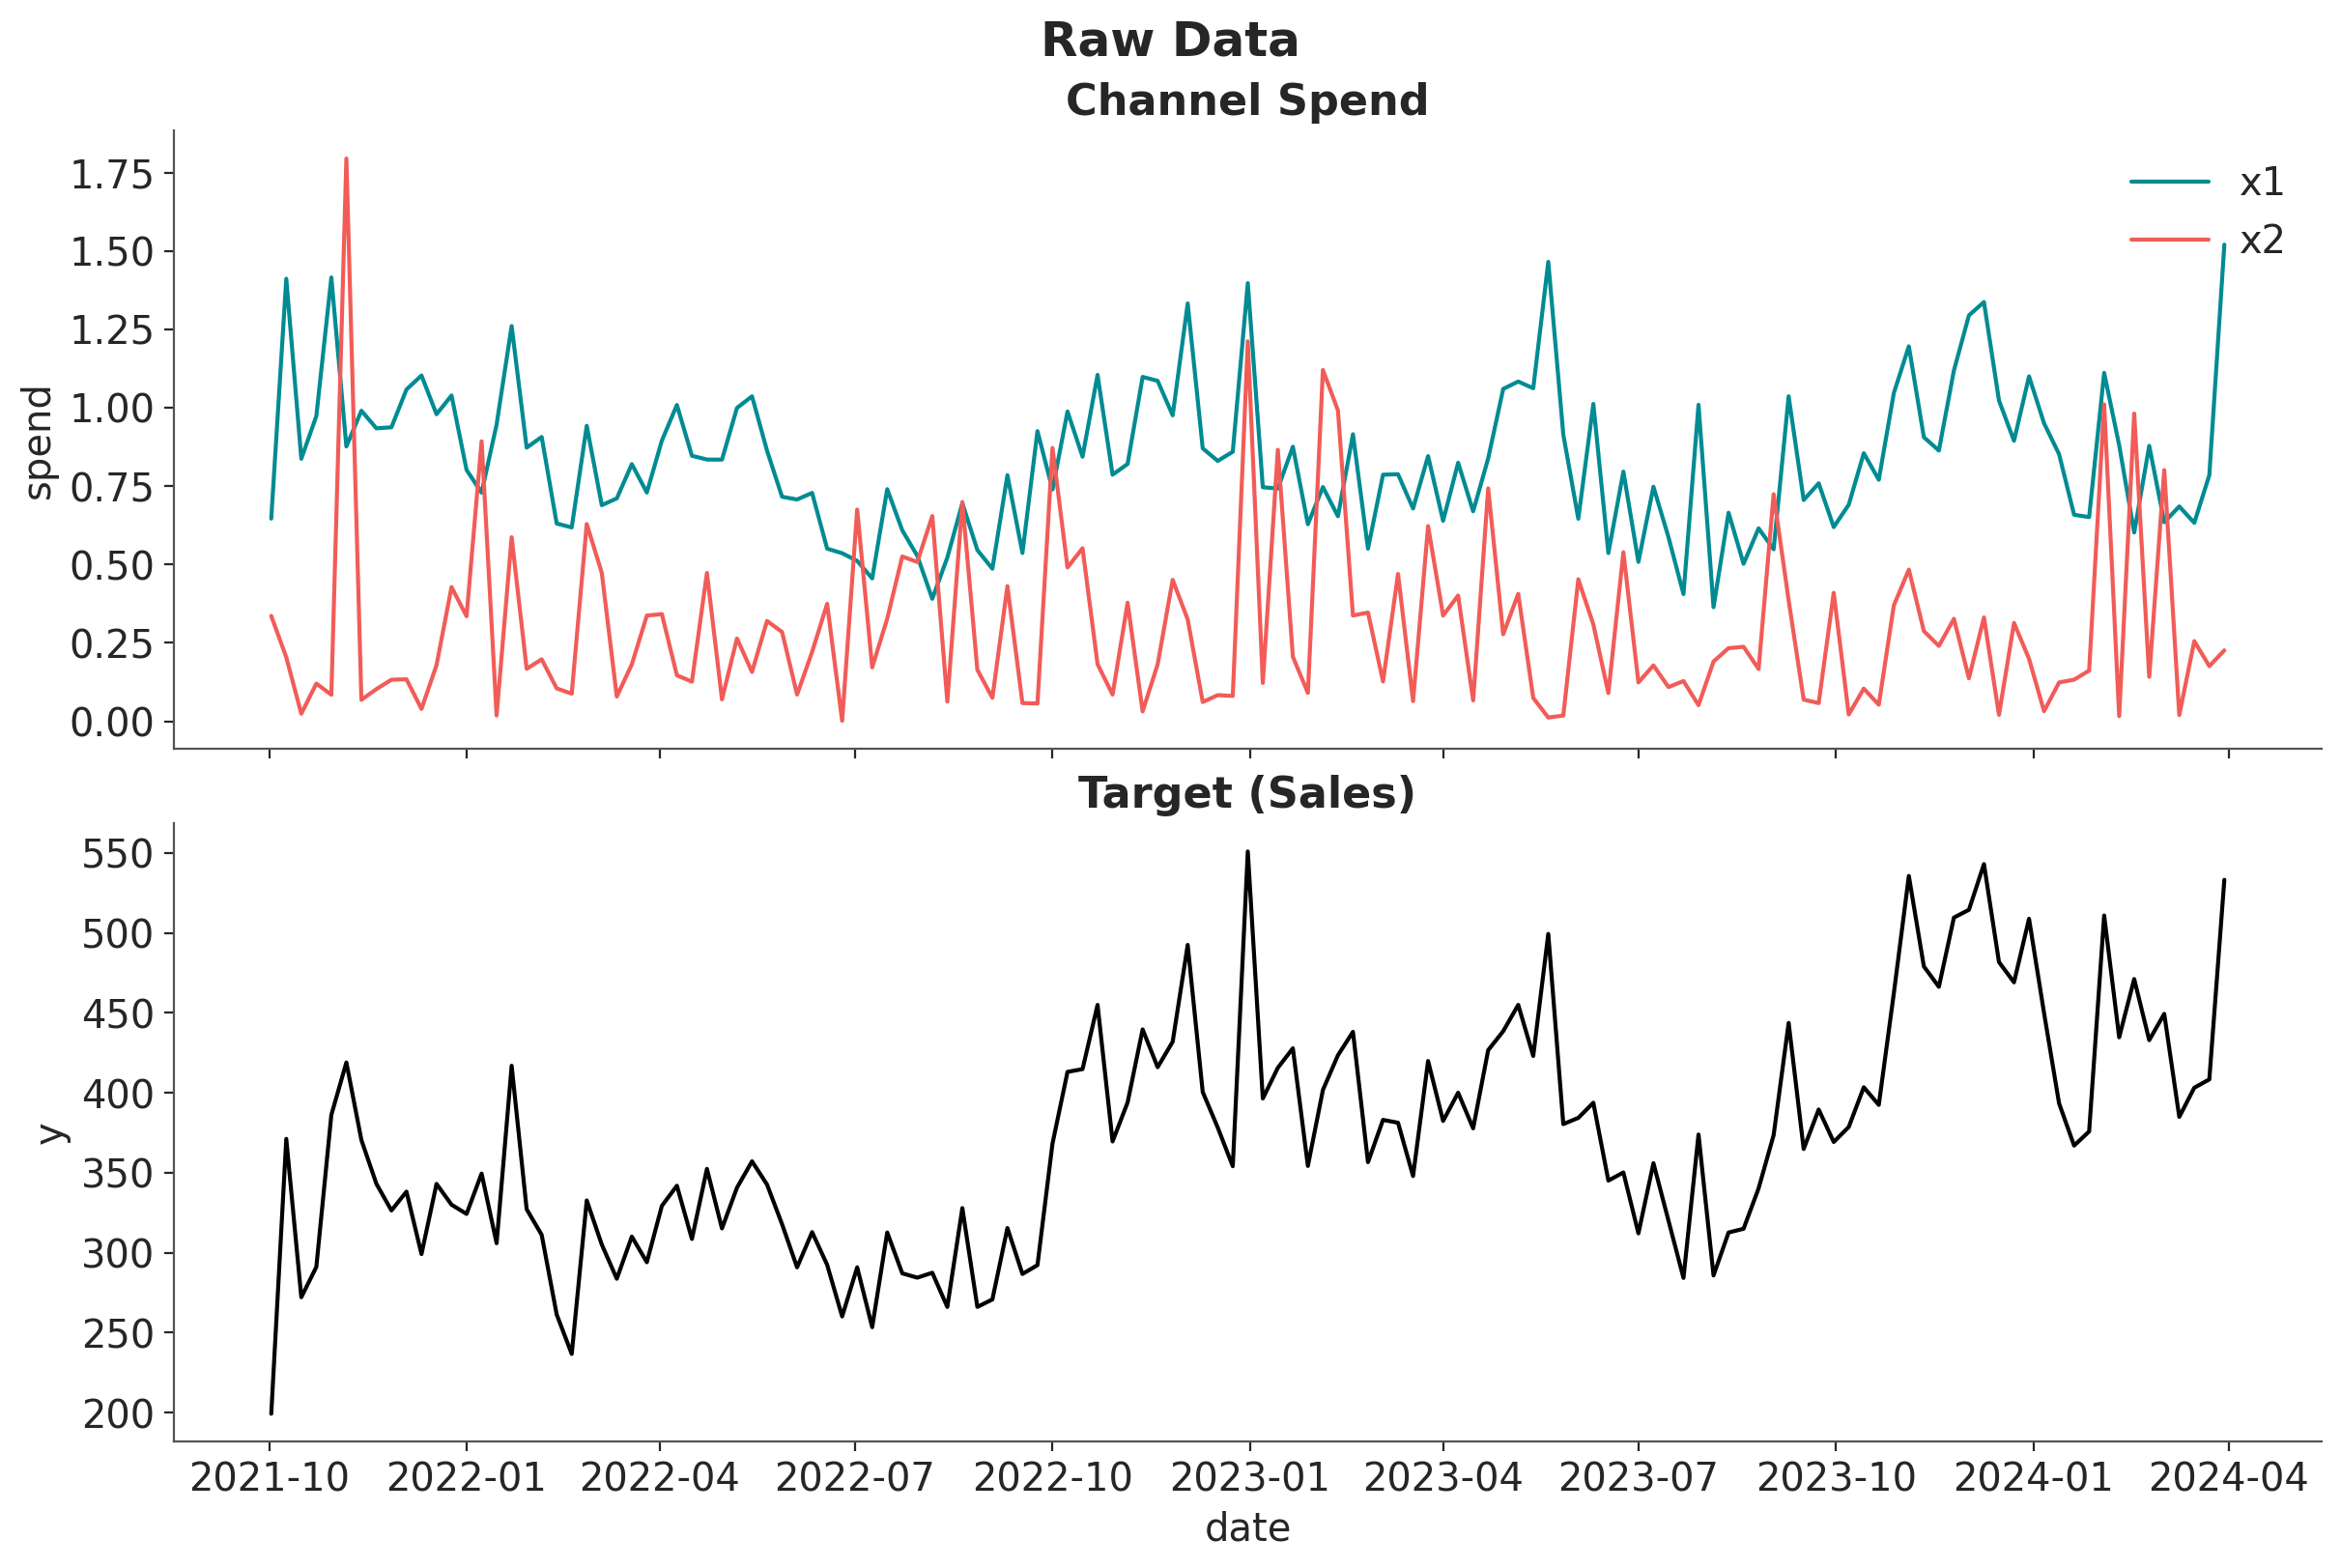

In [6]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
    layout="constrained",
)
for i, ch in enumerate(channels):
    sns.lineplot(data=model_df, x="date", y=ch, color=f"C{i}", label=ch, ax=ax[0])
ax[0].legend(loc="upper right")
ax[0].set(ylabel="spend", title="Channel Spend")

sns.lineplot(data=model_df, x="date", y=target, color="black", ax=ax[1])
ax[1].set(ylabel=target, title="Target (Sales)")
fig.suptitle("Raw Data", fontsize=18, fontweight="bold");

### True ROAS (Ground Truth)

The dataset contains potential outcome columns `y01` (sales without $x_1$) and `y02` (sales without $x_2$). We compute the true global ROAS as:

$$
\text{ROAS}_m = \frac{\sum_t (y_t - y_{0m,t})}{\sum_t x_{m,t}}
$$

In [7]:
roas_true_x1 = (raw_df["y"] - raw_df["y01"]).sum() / raw_df["x1"].sum()
roas_true_x2 = (raw_df["y"] - raw_df["y02"]).sum() / raw_df["x2"].sum()

print(f"True ROAS x1: {roas_true_x1:.2f}")
print(f"True ROAS x2: {roas_true_x2:.2f}")

True ROAS x1: 93.39
True ROAS x2: 171.41


## Data Preparation and Scaling

We scale the data using `MaxAbsScaler` to improve sampling efficiency (we could also do the scaling manually but this shows how to integrate PyMC posterior distributions with [scikit-learn](https://scikit-learn.org/stable/) transformers). The time index, target, and channels are each scaled independently.

In [8]:
date = model_df["date"]
dayofyear = DataArray(model_df["dayofyear"], dims="date")

index_scaler = MaxAbsScaler()
index_scaled = index_scaler.fit_transform(
    model_df.reset_index(drop=False)[["index"]]
).flatten()

target_scaler = MaxAbsScaler()
target_scaled = target_scaler.fit_transform(model_df[[target]]).flatten()

channels_scaler = MaxAbsScaler()
channels_scaled = DataArray(
    channels_scaler.fit_transform(model_df[channels]), dims=("date", "channel")
)

Let's look into the channel spend share:

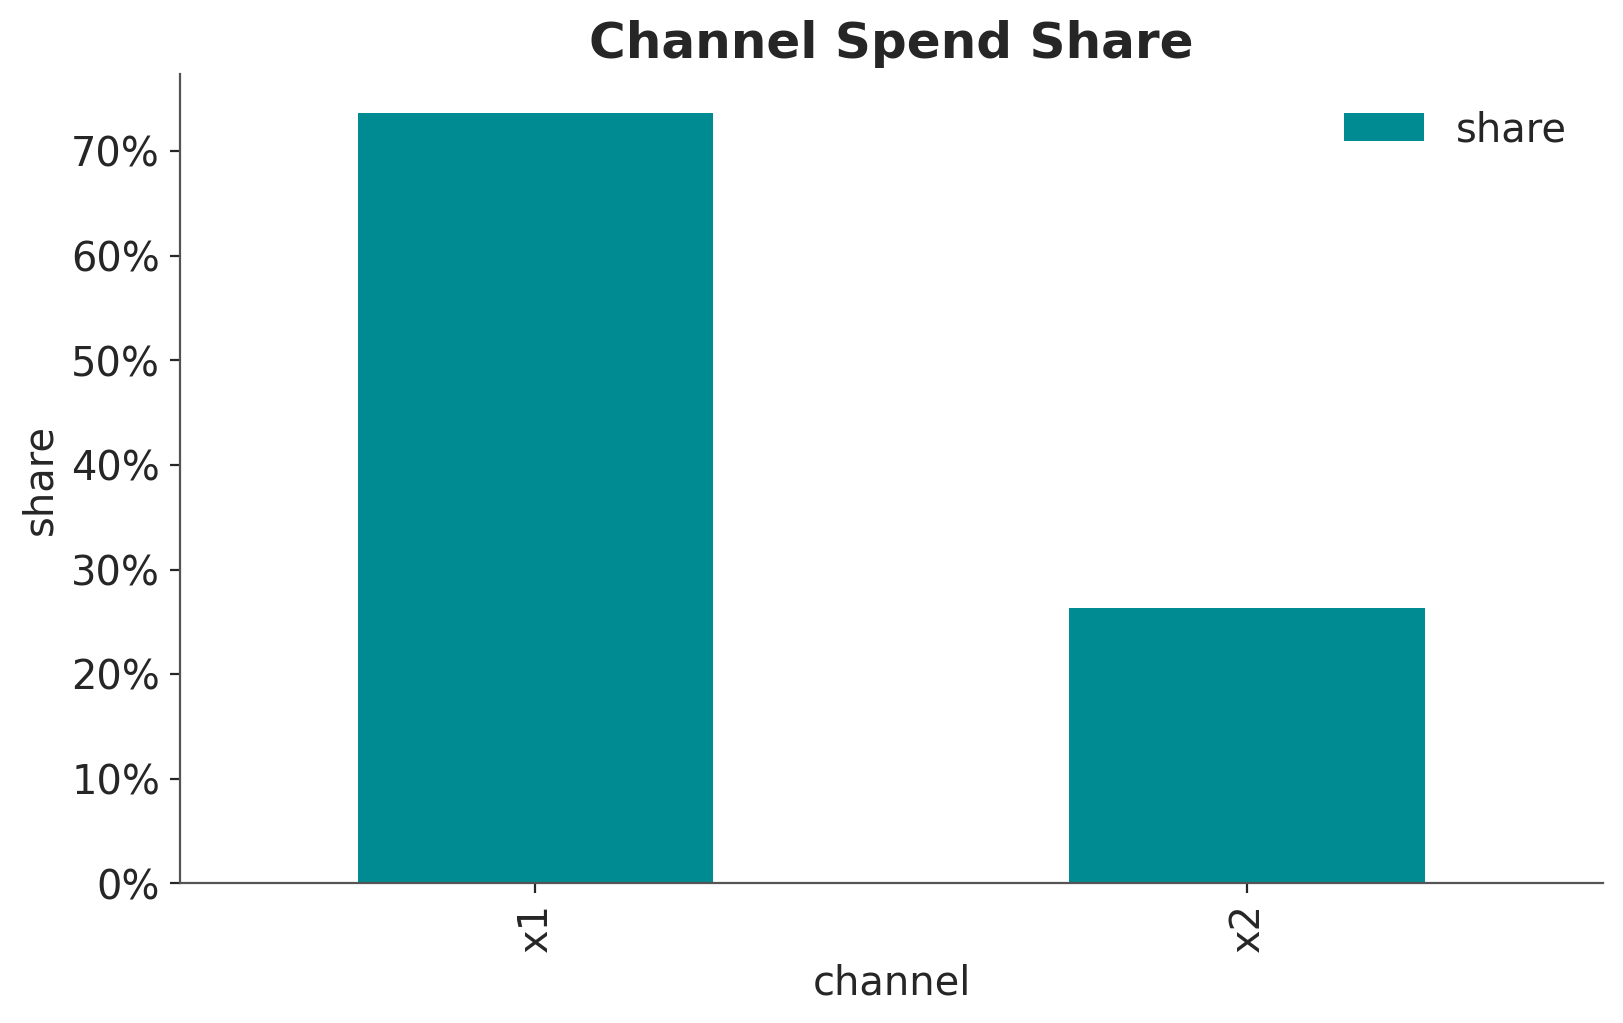

In [9]:
channel_share = DataArray(
    (raw_df[channels].sum() / raw_df[channels].sum().sum()),
    dims="channel",
)

fig, ax = plt.subplots(figsize=(8, 5))
channel_share.to_dataframe("share").plot.bar(ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set(xlabel="channel", ylabel="share")
ax.set_title("Channel Spend Share", fontsize=18, fontweight="bold");

## Model Components Setup

We define reusable PyMC-Marketing components for adstock and seasonality. For the saturation transform, we use the raw `logistic_saturation` function (without the `LogisticSaturation` class) because we need to handle the channel scaling coefficient $\beta$ separately in each model: the baseline uses a direct prior, while the calibrated model derives it from ROAS.

In [10]:
l_max = 4

adstock = GeometricAdstock(
    l_max=l_max,
    normalize=True,
    priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
)

yearly_fourier = YearlyFourier(
    n_order=3,
    prior=Prior("Normal", mu=0, sigma=1, dims="fourier"),
)

## Baseline Model: Standard Beta Priors (No Confounder)

This model excludes the confounder $z$ and uses standard `HalfNormal` priors on `beta_channel`, weighted by each channel's spend share. We expect the ROAS of $x_1$ to be heavily overestimated due to the open backdoor path through $z$.

```{tip}
We will add a time-varying intercept using a [Hilbert Space Gaussian Process](https://docs.pymc.io/en/latest/api/gp.html#pymc.gp.HSGP). For details on the choice of priors, see the original blog post [Media Mix Modeling with PyMC-Marketing](https://juanitorduz.github.io/mmm_roas/) and the PyMC example [Gaussian Processes: HSGP Reference & First Steps](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/HSGP-Basic.html).
```

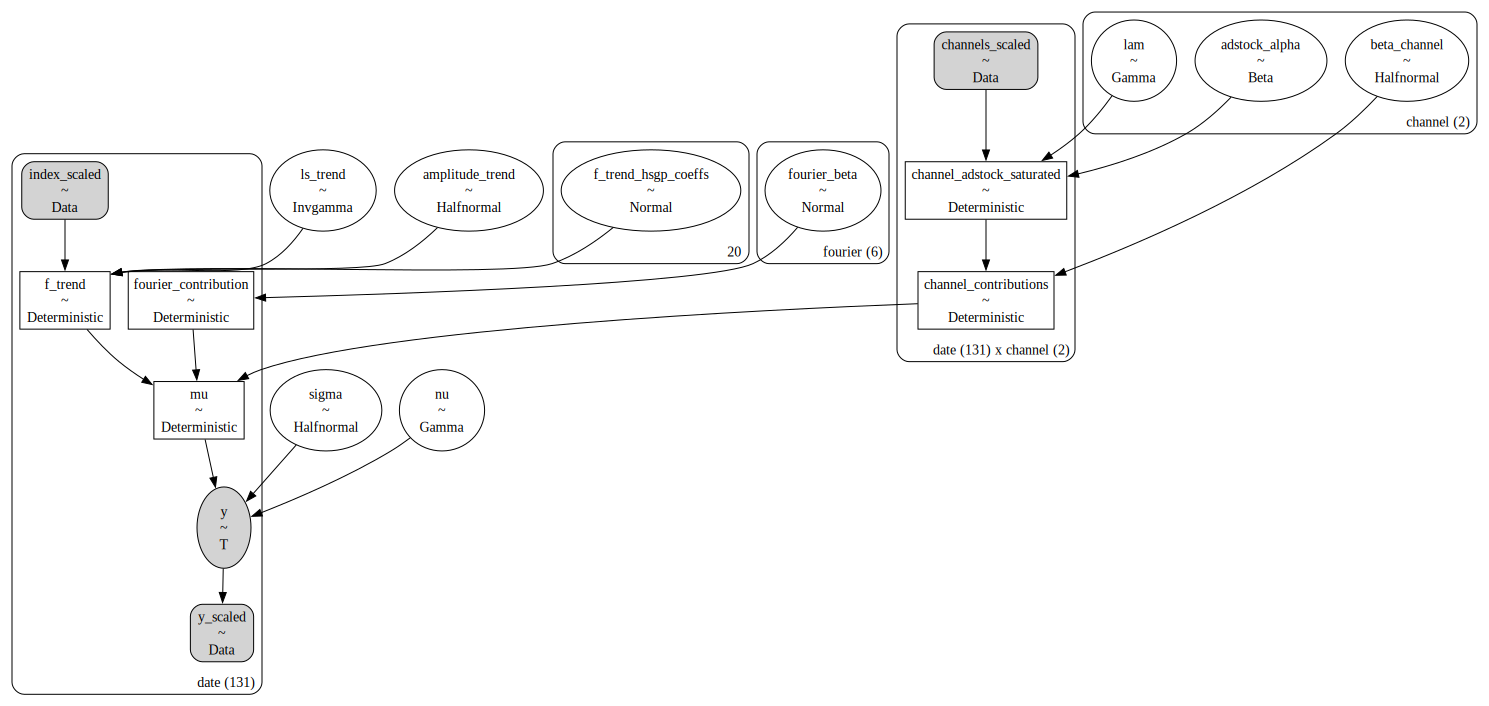

In [11]:
coords = {"date": date, "channel": channels}

with pm.Model(coords=coords) as model_baseline:
    # --- Data Containers ---
    index_data = pm.Data("index_scaled", index_scaled, dims="date")
    channels_data = pmd.Data(
        "channels_scaled", channels_scaled, dims=("date", "channel")
    )
    y_data = pmd.Data("y_scaled", target_scaled, dims="date")

    # --- HSGP Trend ---
    amplitude_trend = pm.HalfNormal("amplitude_trend", sigma=1)

    ls_trend = pz.maxent(
        distribution=pz.InverseGamma(),
        lower=0.1,
        upper=0.9,
        mass=0.95,
        plot=False,
    ).to_pymc("ls_trend")

    cov_trend = amplitude_trend * pm.gp.cov.ExpQuad(input_dim=1, ls=ls_trend)
    gp_trend = pm.gp.HSGP(m=[20], c=1.5, cov_func=cov_trend)
    f_trend = gp_trend.prior("f_trend", X=index_data[:, None], dims="date")
    f_trend = ptx.as_xtensor(f_trend, dims=("date",))

    # --- Channel Effects ---
    lam = pmd.Gamma("lam", alpha=2, beta=2, dims="channel")
    beta_channel = pmd.HalfNormal("beta_channel", sigma=channel_share, dims="channel")

    adstocked = adstock.apply(channels_data, core_dim="date")
    channel_adstock_saturated = pmd.Deterministic(
        "channel_adstock_saturated",
        logistic_saturation(adstocked, lam=lam),
        dims=("date", "channel"),
    )
    channel_contributions = pmd.Deterministic(
        "channel_contributions",
        channel_adstock_saturated * beta_channel,
        dims=("date", "channel"),
    )

    # --- Seasonality ---
    fourier_contribution = pmd.Deterministic(
        "fourier_contribution",
        yearly_fourier.apply(dayofyear),
        dims="date",
    )

    # --- Mean ---
    mu = pmd.Deterministic(
        "mu",
        f_trend + channel_contributions.sum(dim="channel") + fourier_contribution,
        dims="date",
    )

    # --- Likelihood ---
    sigma = pm.HalfNormal("sigma", sigma=1)
    nu = pm.Gamma("nu", alpha=25, beta=2)
    pmd.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y_data, dims="date")

pm.model_to_graphviz(model_baseline)

### Fit Model

In [12]:
with model_baseline:
    idata_baseline = pm.sample(
        target_accept=0.95,
        tune=1_500,
        draws=1_000,
        chains=4,
        nuts_sampler="nutpie",
        random_seed=rng,
    )
    posterior_predictive_baseline = pm.sample_posterior_predictive(
        trace=idata_baseline, random_seed=rng
    )

NUTS[nutpie]: [amplitude_trend, ls_trend, f_trend_hsgp_coeffs, lam, beta_channel, adstock_alpha, fourier_beta, sigma, nu]


Output()

Sampling: [y]


Output()

### Channel Contributions vs True Effects

We compare estimated channel contributions against the ground truth. The omitted confounder $z$ causes $x_1$'s contribution to be heavily overestimated.

First, let's do some proper scaling back to the original data.

In [13]:
pp_mu_baseline = xr.apply_ufunc(
    target_scaler.inverse_transform,
    idata_baseline["posterior"]["mu"].expand_dims(dim={"_": 1}, axis=-1),
    input_core_dims=[["date", "_"]],
    output_core_dims=[["date", "_"]],
    vectorize=True,
).squeeze(dim="_")

pp_contributions_baseline = xr.apply_ufunc(
    target_scaler.inverse_transform,
    idata_baseline["posterior"]["channel_contributions"],
    input_core_dims=[["date", "channel"]],
    output_core_dims=[["date", "channel"]],
    vectorize=True,
)

Now we can plot the estimated channel contributions against the true effects.

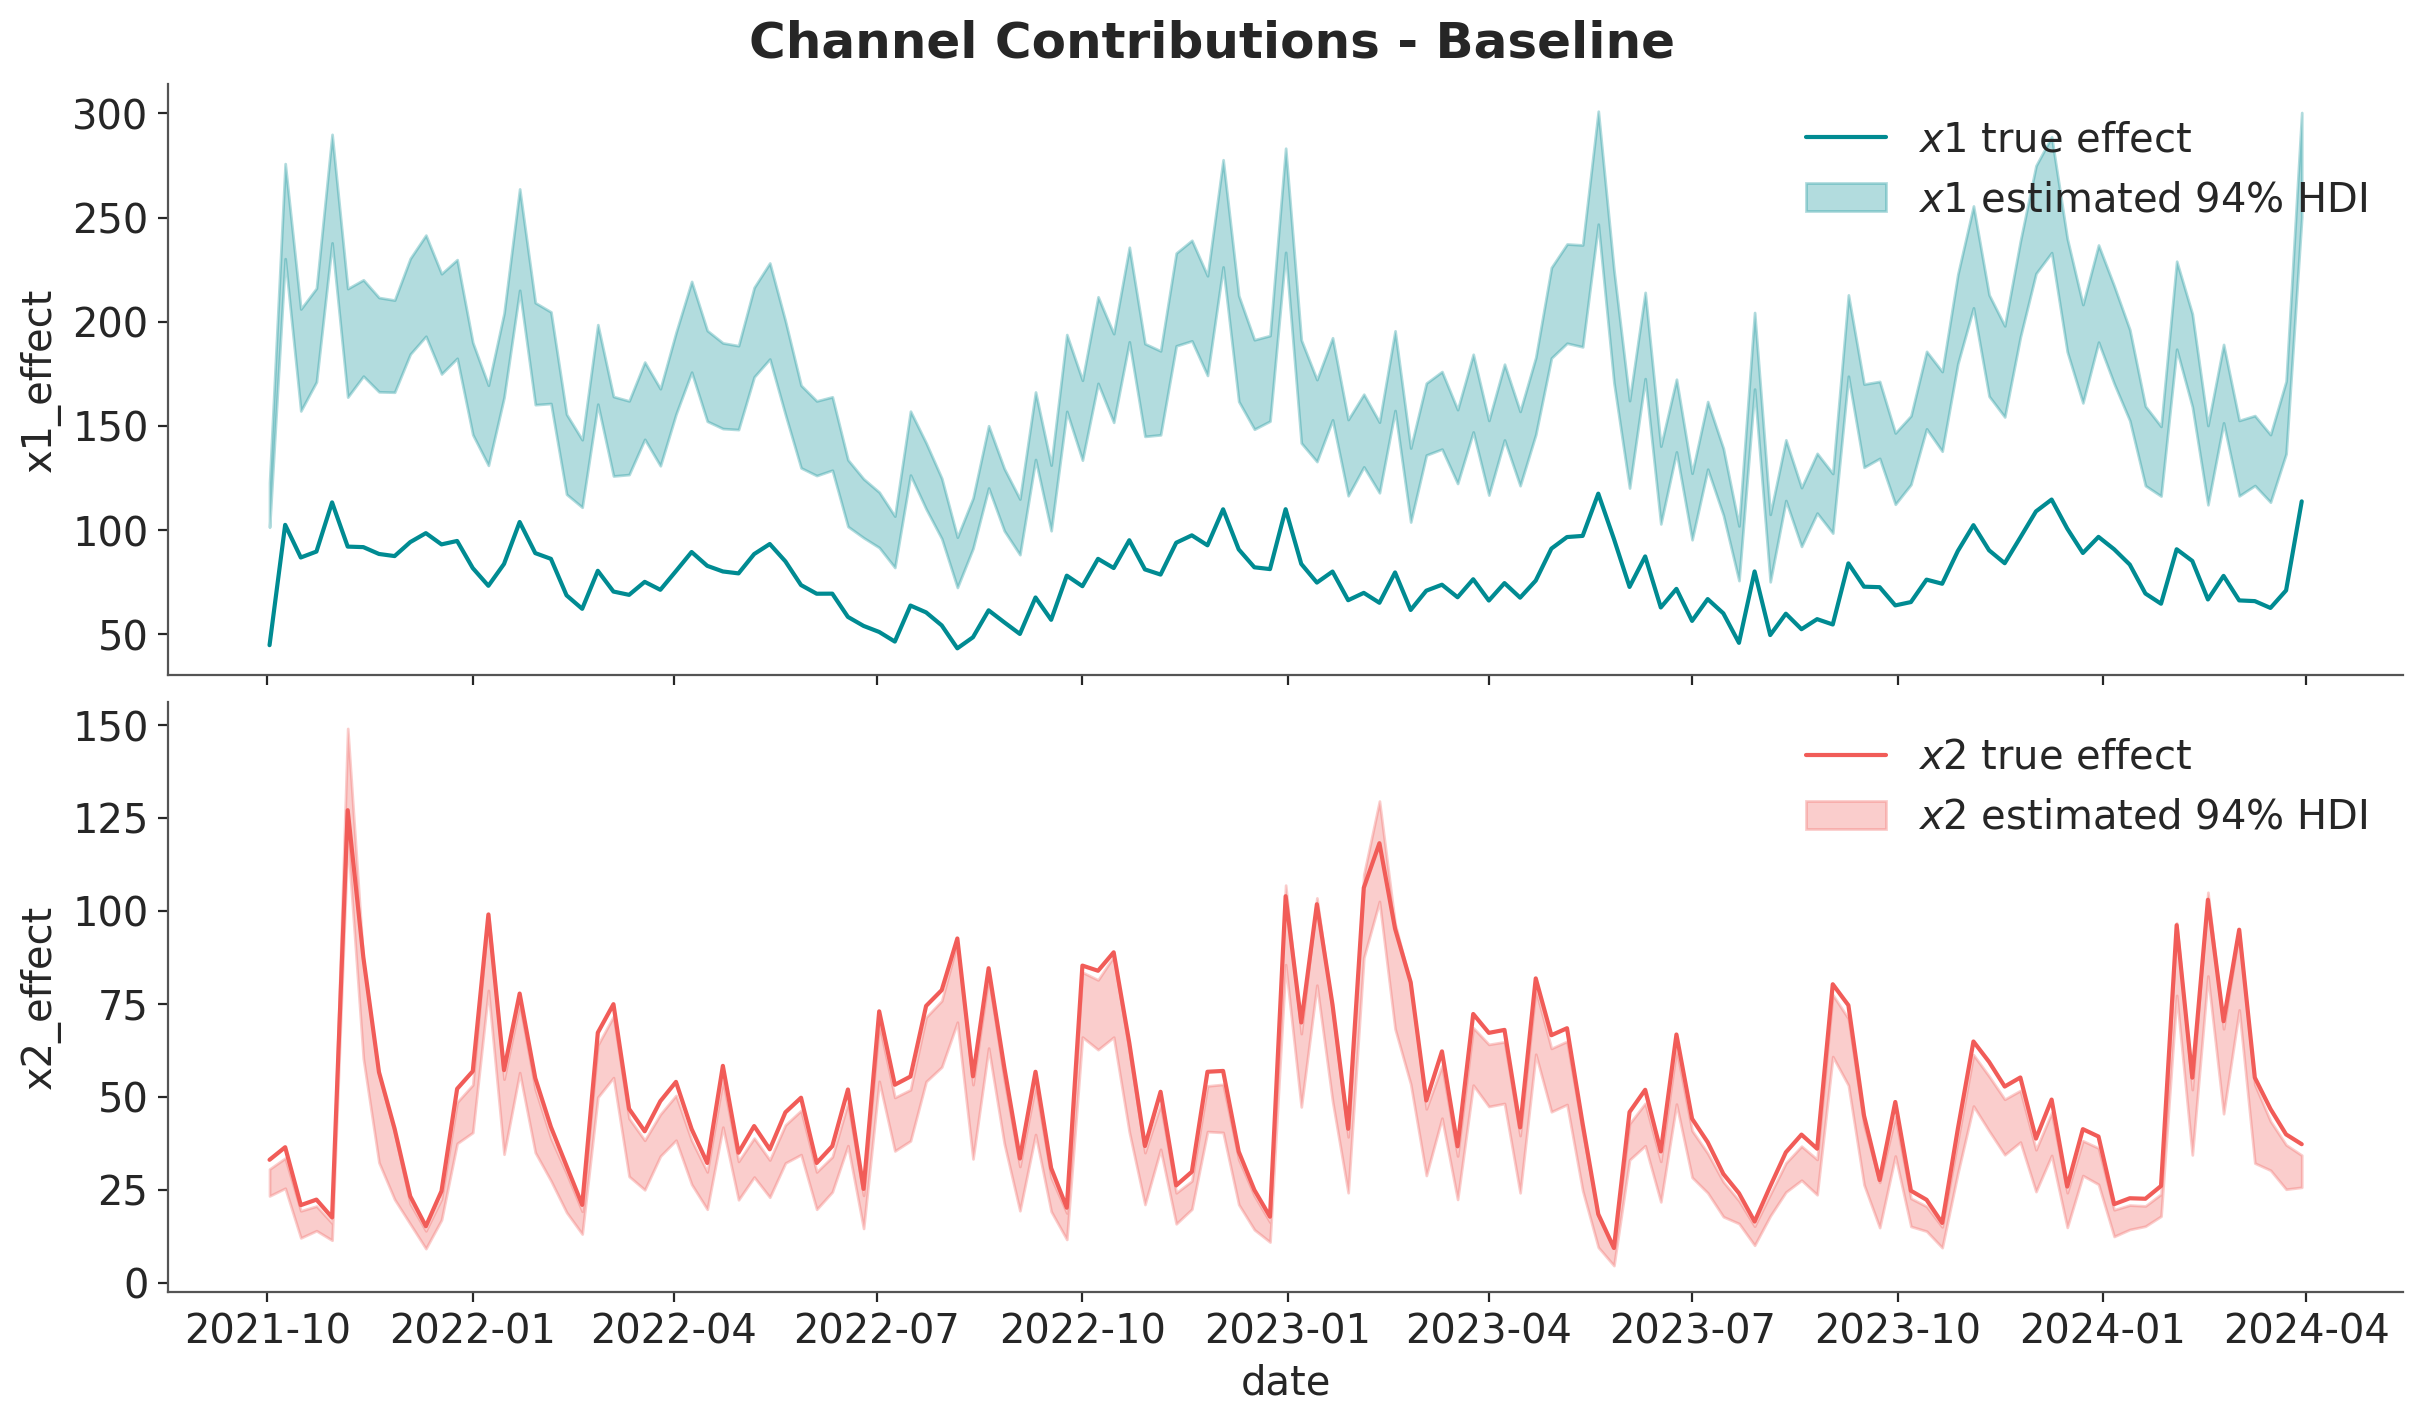

In [14]:
amplitude = 100

fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 7), sharex=True, layout="constrained"
)
for i, ch in enumerate(channels):
    sns.lineplot(
        x="date",
        y=f"{ch}_effect",
        data=raw_df.assign(
            **{f"{ch}_effect": lambda df, c=ch: amplitude * df[f"{c}_effect"]}
        ),
        color=f"C{i}",
        label=rf"${ch}$ true effect",
        ax=ax[i],
    )
    hdi = az.hdi(pp_contributions_baseline.sel(channel=ch), prob=0.94)
    ax[i].fill_between(
        date,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color=f"C{i}",
        alpha=0.3,
        label=rf"${ch}$ estimated $94\%$ HDI",
    )
    ax[i].legend(loc="upper right")
fig.suptitle("Channel Contributions - Baseline", fontsize=18, fontweight="bold");

We clearly see the confounding bias from the omitted variable $z$ in the $x_1$ contribution estimation. Let's see how this bias gets translated into ROAS.

### ROAS Estimation (Baseline)

We compute the global ROAS by generating counterfactual predictions with each channel set to zero.

In [15]:
predictions_roas_baseline = {}

for channel in channels:
    with model_baseline:
        pm.set_data(
            new_data={
                "channels_scaled": channels_scaler.transform(
                    raw_df[channels].assign(**{channel: 0})
                )
            }
        )
        preds = pm.sample_posterior_predictive(
            trace=idata_baseline,
            var_names=["mu"],
            progressbar=False,
            random_seed=rng,
        )

    mu_counterfactual = xr.apply_ufunc(
        target_scaler.inverse_transform,
        preds["posterior_predictive"]["mu"].expand_dims(dim={"_": 1}, axis=-1),
        input_core_dims=[["date", "_"]],
        output_core_dims=[["date", "_"]],
        vectorize=True,
    ).squeeze(dim="_")

    diff = pp_mu_baseline - mu_counterfactual
    predictions_roas_baseline[channel] = diff.sum(dim="date") / raw_df[channel].sum()

Sampling: []


Sampling: []


Let's visualize the results.

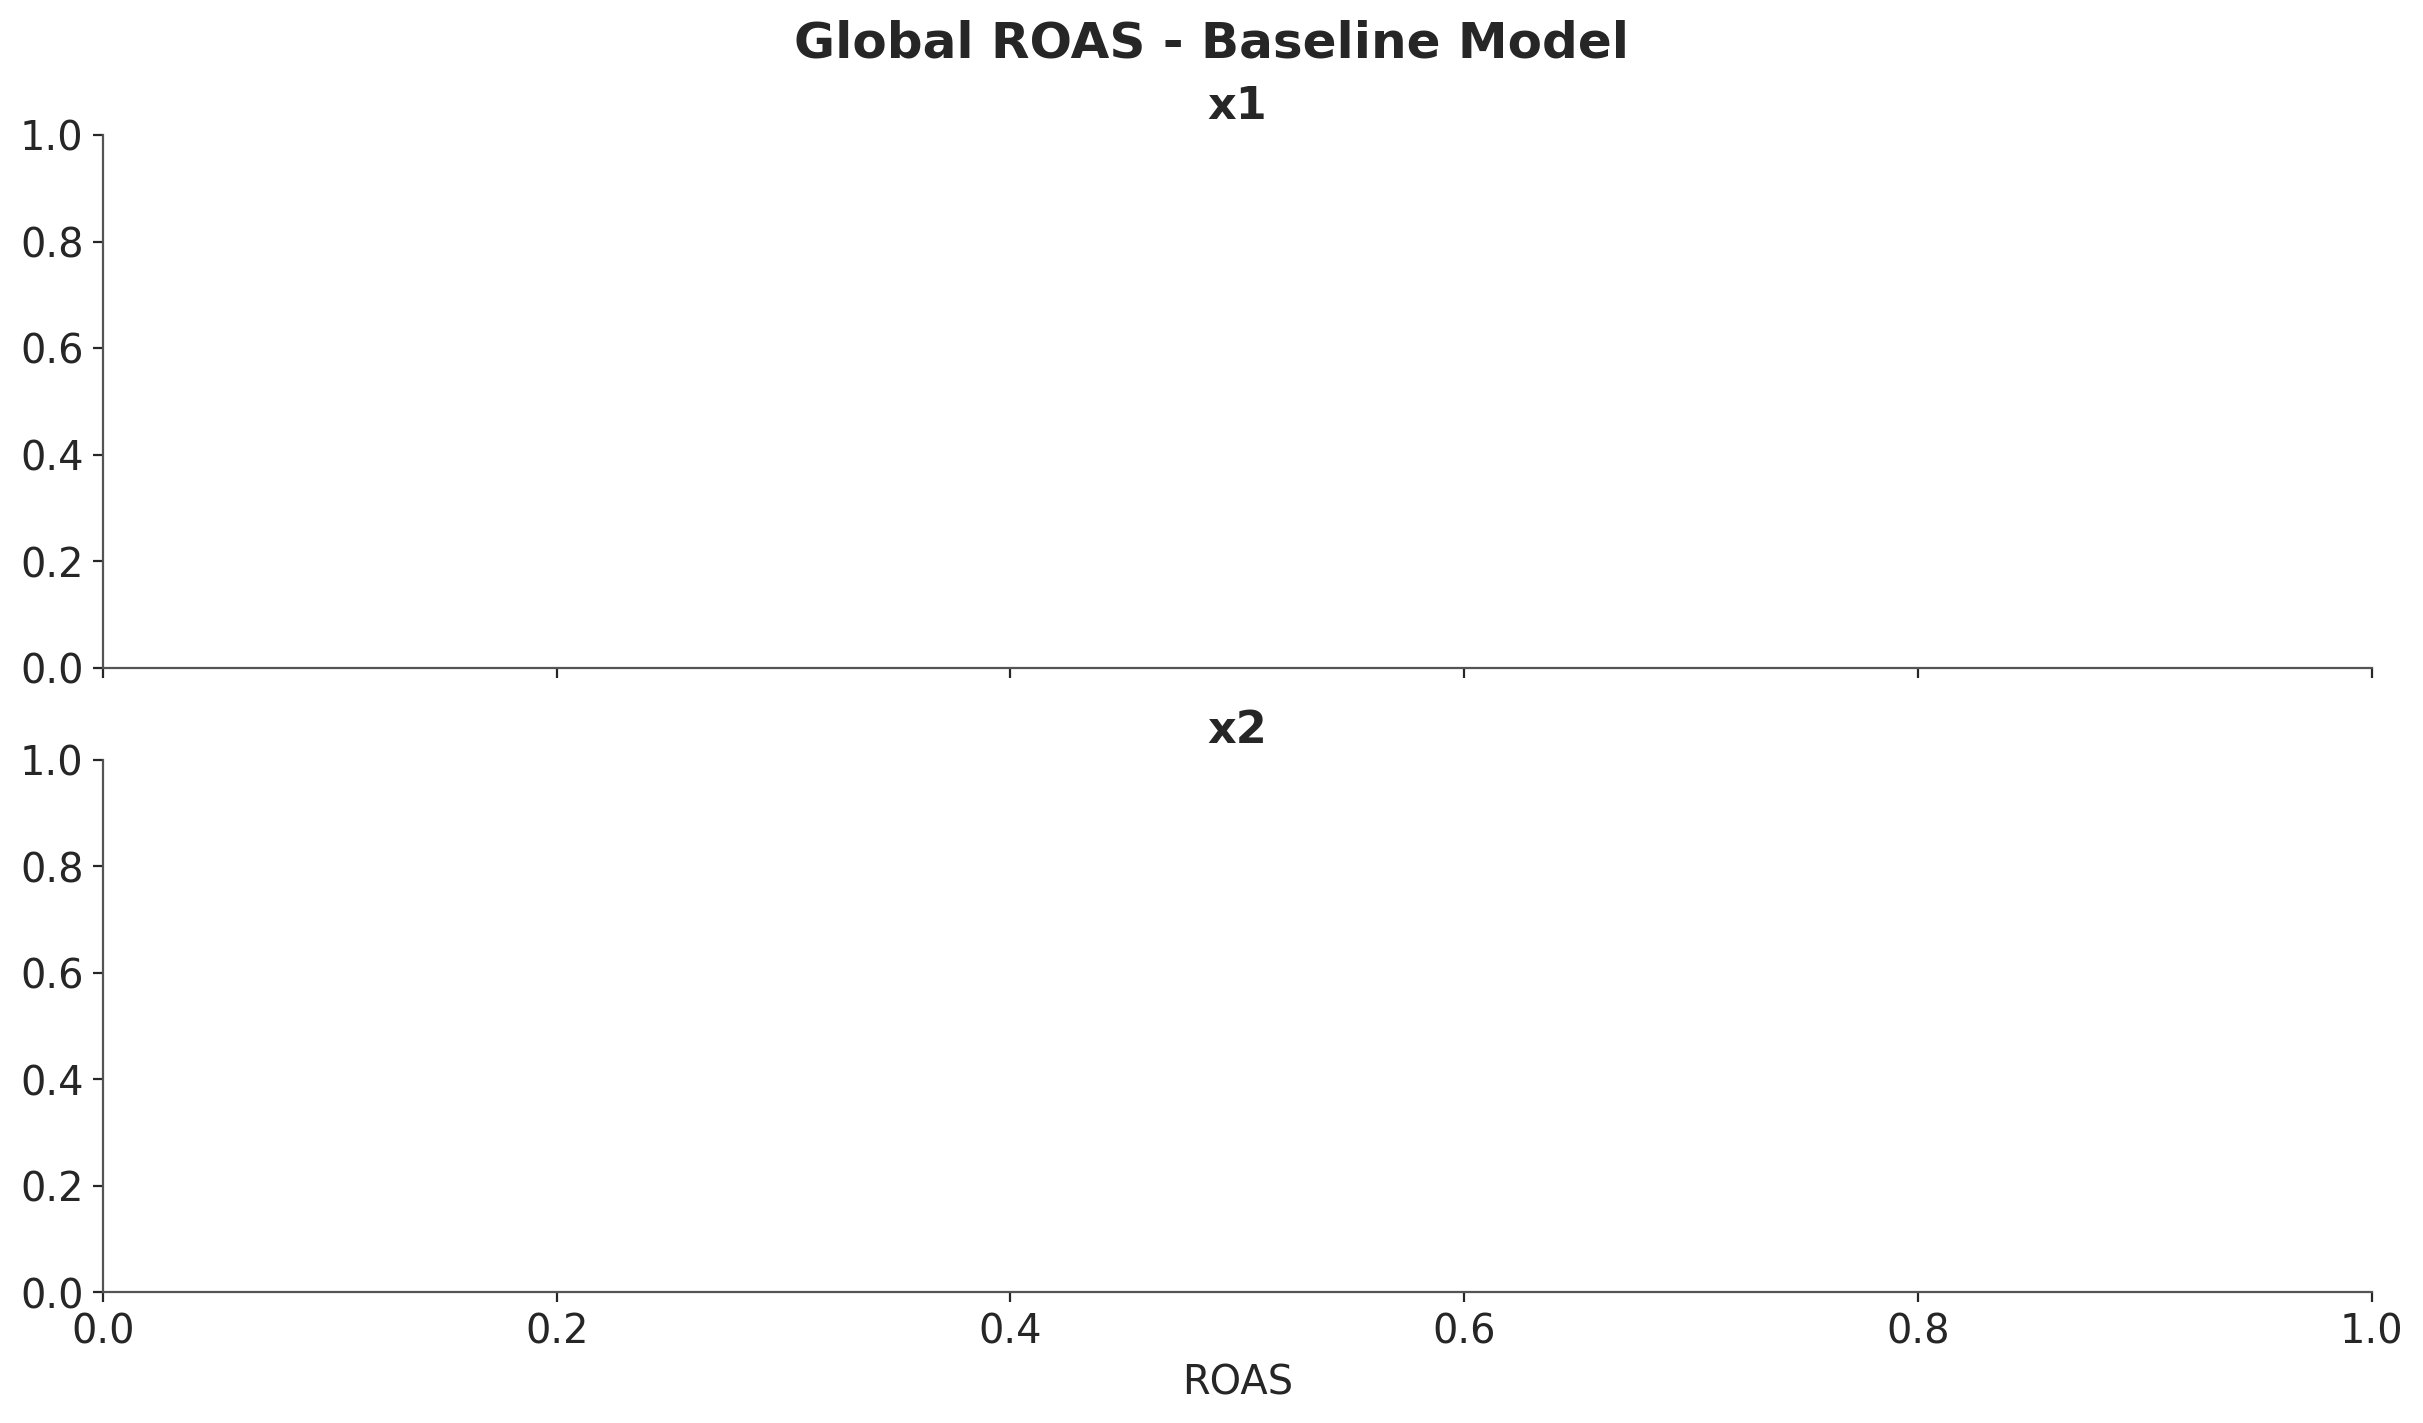

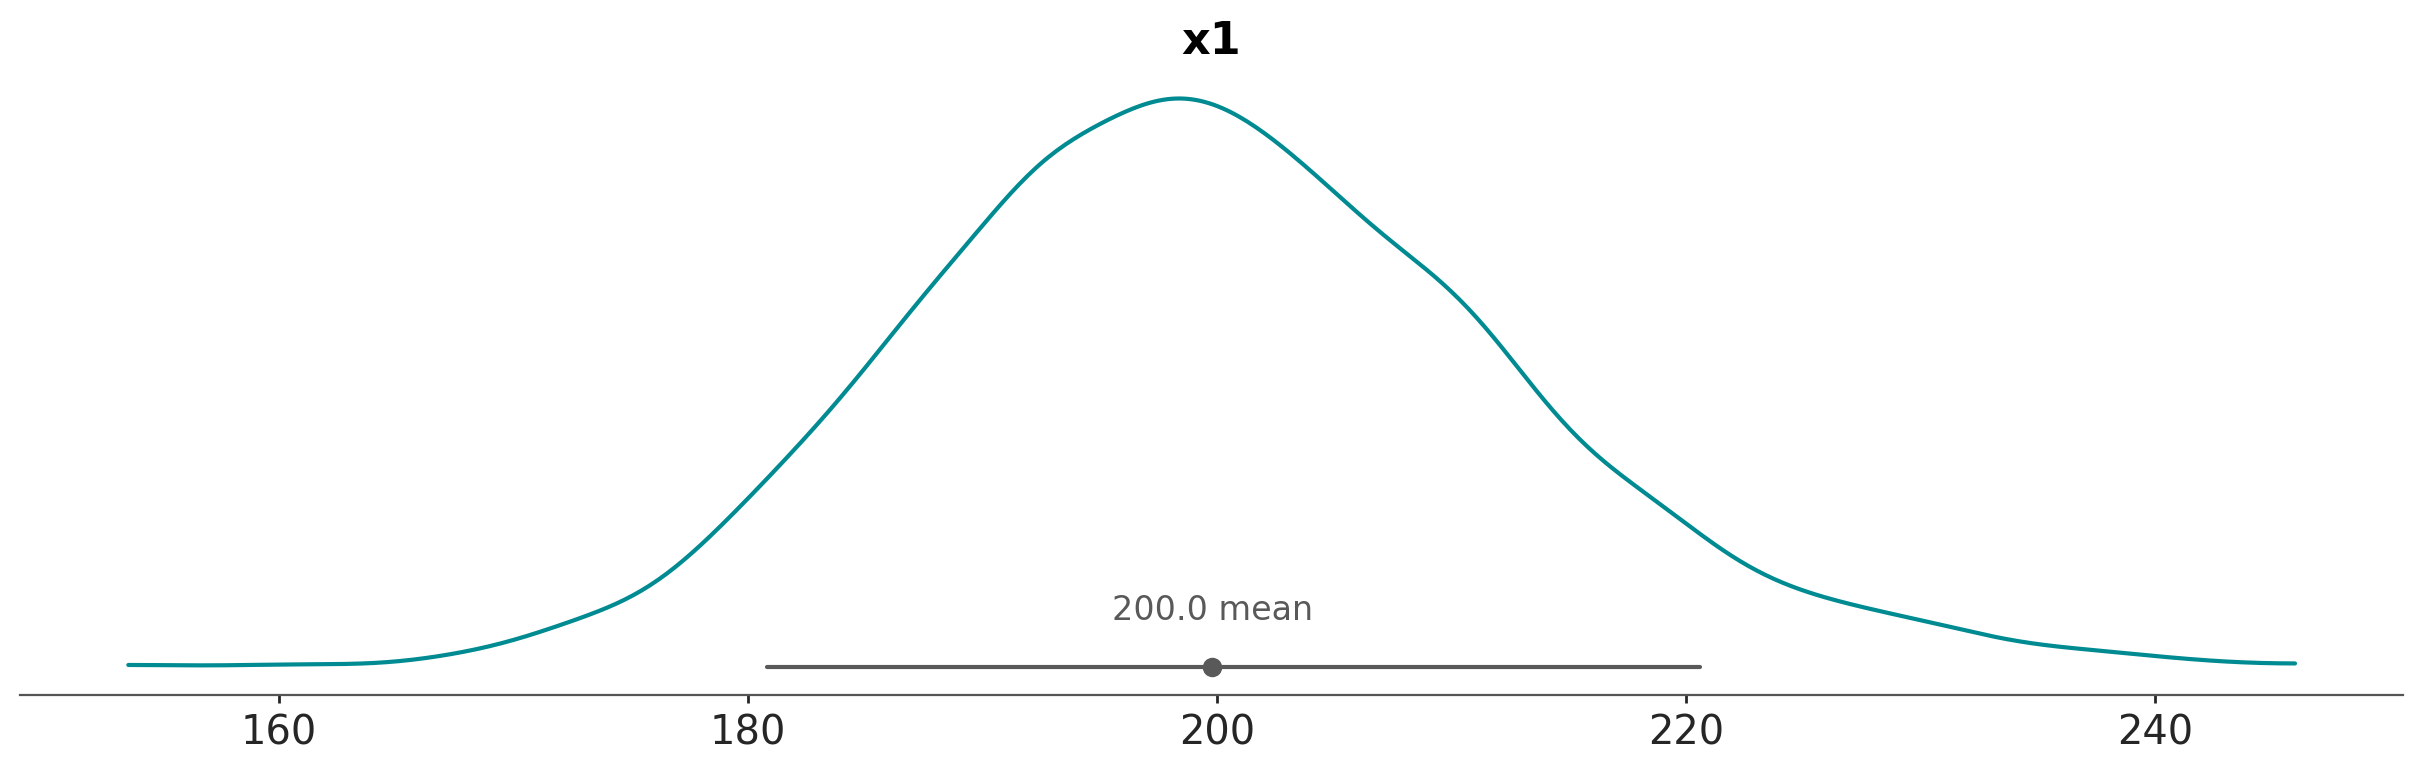

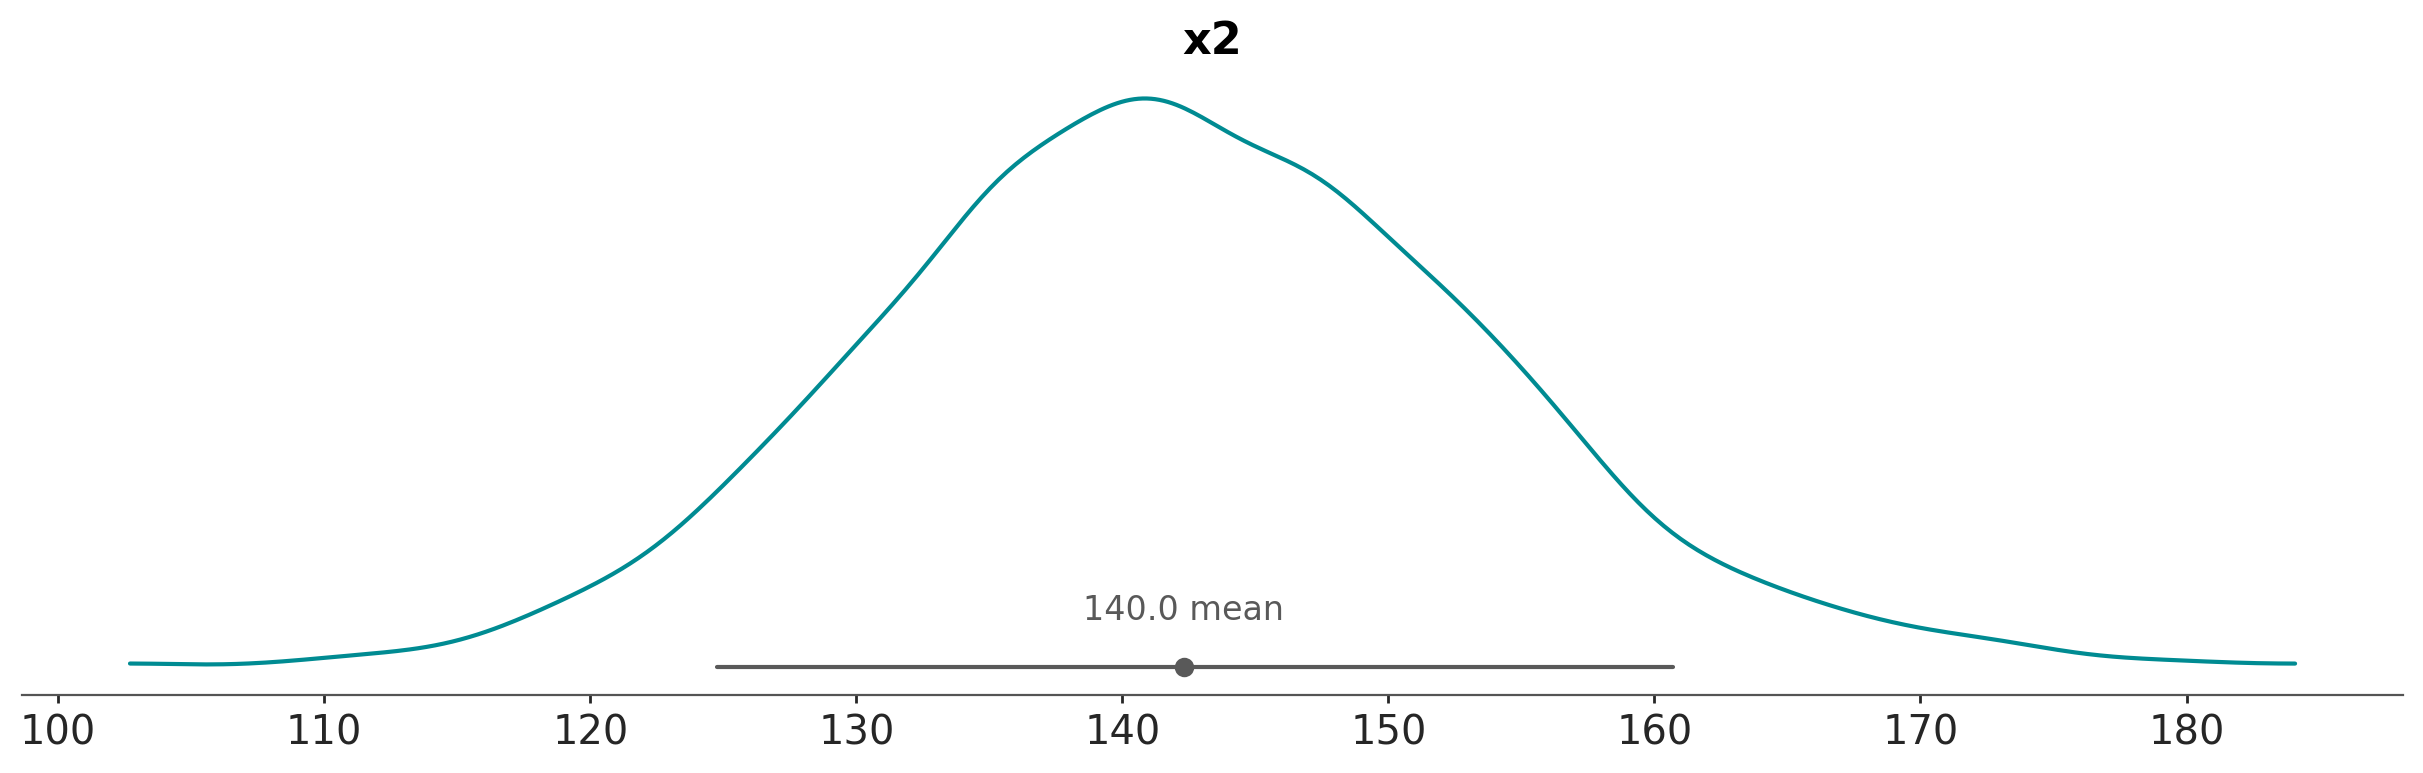

In [16]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 7), sharex=True, layout="constrained"
)
azp.plot_dist(
    xr.Dataset({"x1": predictions_roas_baseline["x1"]}), sample_dims=["sample"]
)
ax[0].set(title="x1")
azp.plot_dist(
    xr.Dataset({"x2": predictions_roas_baseline["x2"]}),
    sample_dims=["sample"],
)
ax[1].set(title="x2", xlabel="ROAS")
fig.suptitle("Global ROAS - Baseline Model", fontsize=18, fontweight="bold");

The baseline model massively overestimates the ROAS of $x_1$ due to the confounding bias from the omitted variable $z$. This is something we already know from the case study {ref}`mmm_roas`.

## Calibrated Model: ROAS Parameterization

We now build the same model structure but replace the `beta_channel` prior with a derived quantity based on ROAS priors. The ROAS values come from hypothetical experiments that provide unbiased estimates close to the true values.

### Experiment Calibration

Suppose experiments yielded the following ROAS estimates:

In [17]:
roas_x1_bar = 95
roas_x2_bar = 170

roas_x1_bar_scaled = roas_x1_bar / target_scaler.scale_.item()
roas_x2_bar_scaled = roas_x2_bar / target_scaler.scale_.item()
roas_bar_scaled = DataArray(
    np.array([roas_x1_bar_scaled, roas_x2_bar_scaled]), dims="channel"
)

error = 30
error_scaled = error / target_scaler.scale_.item()

### ROAS Prior Distributions

We use LogNormal priors centered at the experimental ROAS estimates. The LogNormal ensures positivity and allows for right-skewed uncertainty.

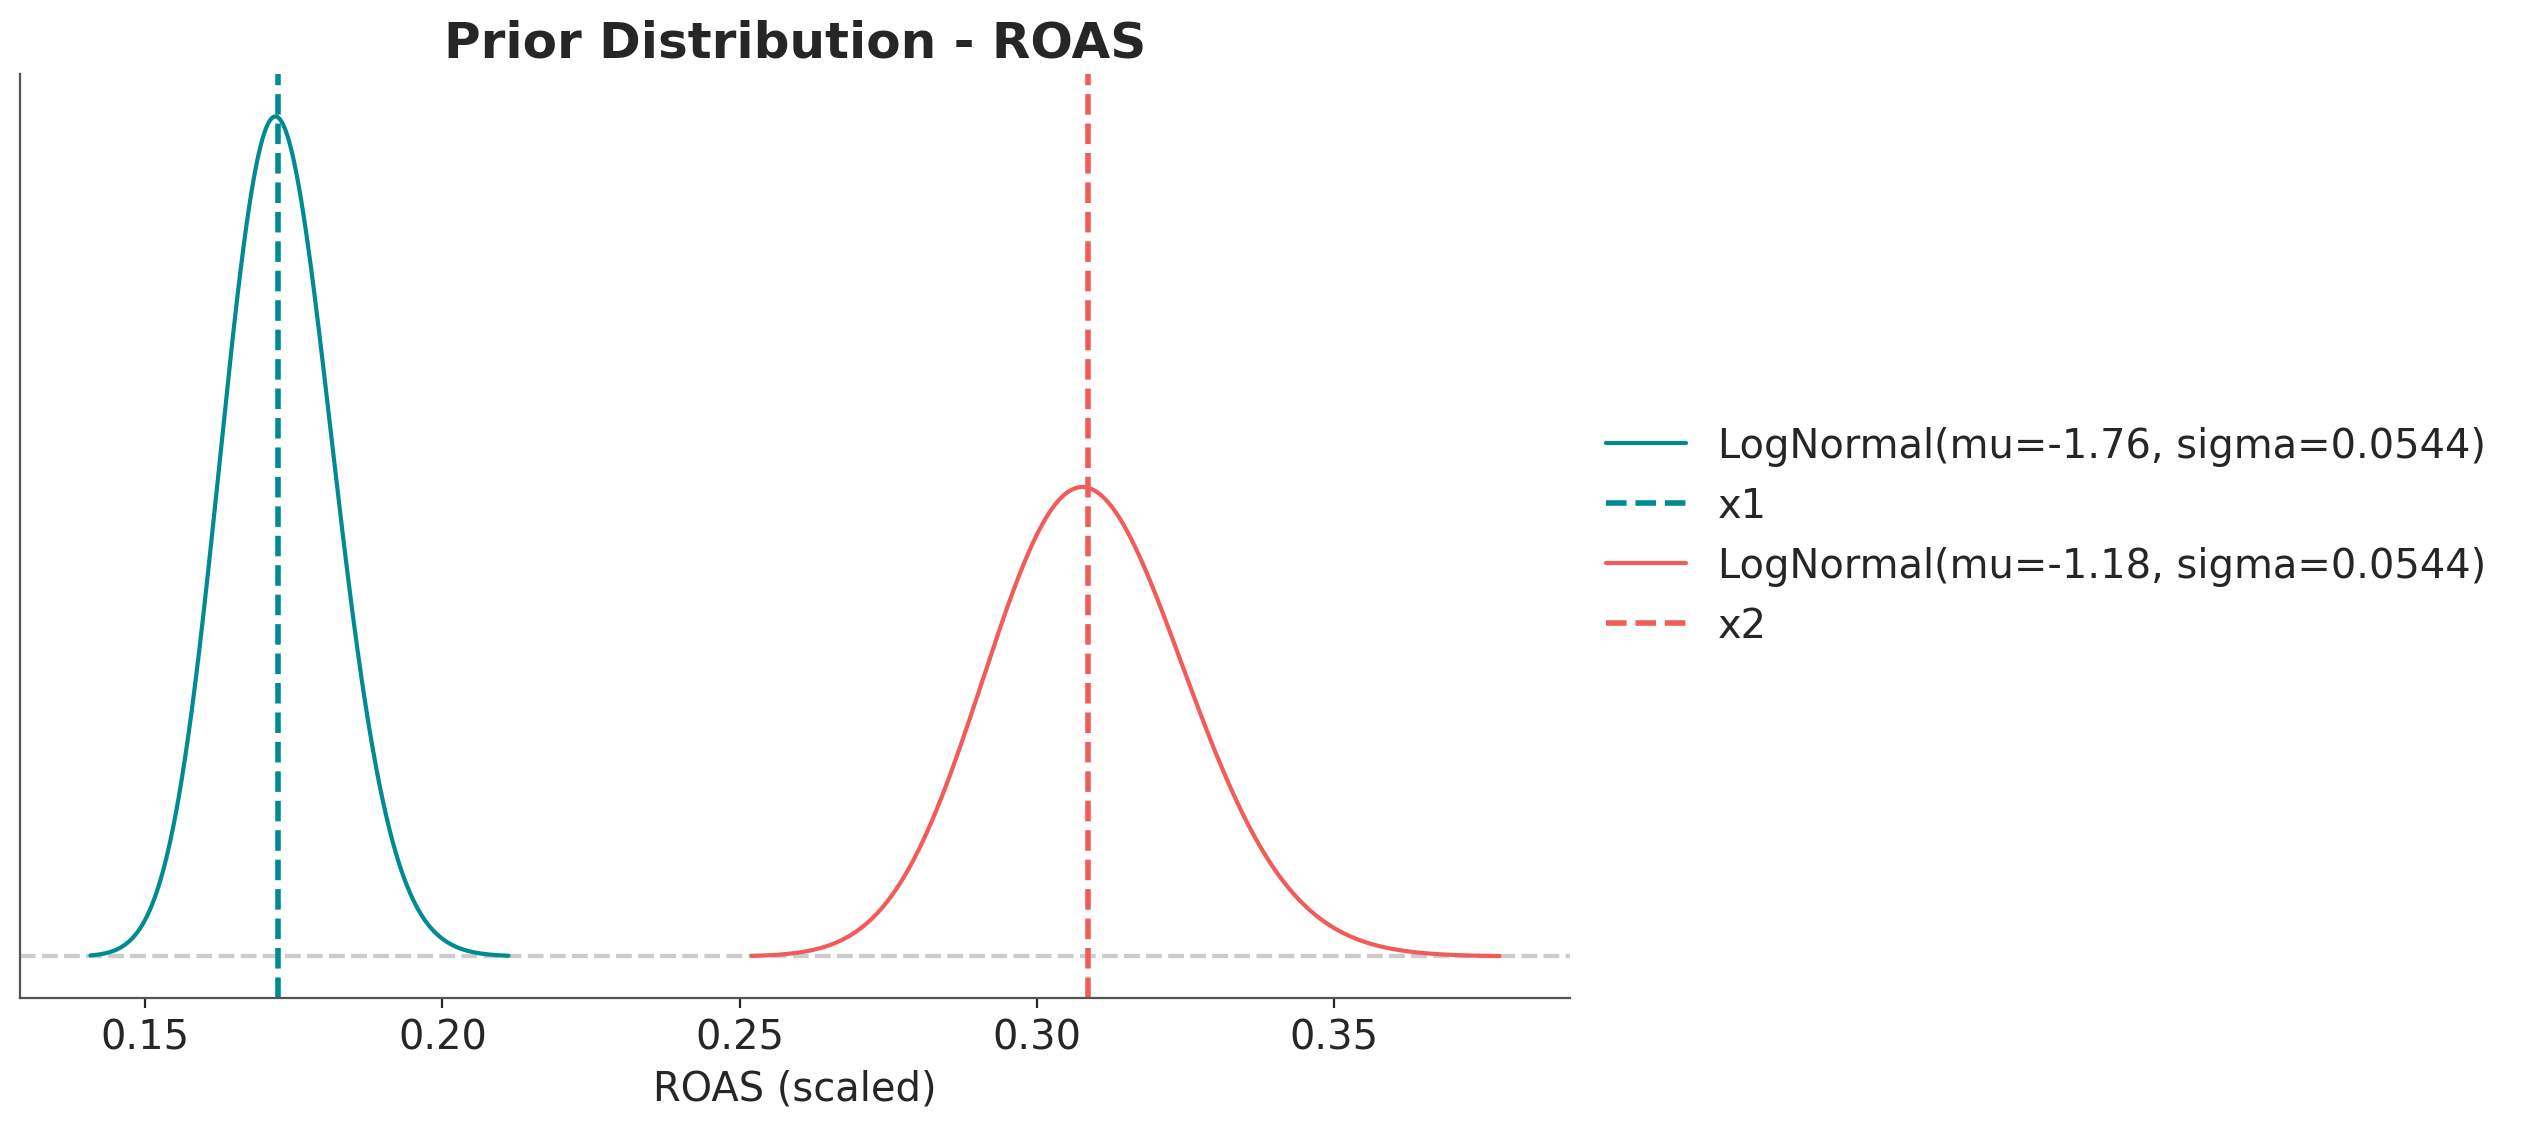

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
pz.LogNormal(mu=np.log(roas_x1_bar_scaled), sigma=error_scaled).plot_pdf(
    color="C0", ax=ax
)
ax.axvline(x=roas_x1_bar_scaled, color="C0", linestyle="--", linewidth=2, label="x1")
pz.LogNormal(mu=np.log(roas_x2_bar_scaled), sigma=error_scaled).plot_pdf(
    color="C1", ax=ax
)
ax.axvline(x=roas_x2_bar_scaled, color="C1", linestyle="--", linewidth=2, label="x2")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(xlabel="ROAS (scaled)")
ax.set_title("Prior Distribution - ROAS", fontsize=18, fontweight="bold");

### Model Specification

The key change from the baseline: instead of `beta_channel ~ HalfNormal(...)`, we define `roas ~ LogNormal(...)` and derive `beta_channel` deterministically:

$$
\beta_m = \frac{\text{ROAS}_m \cdot \sum_t x_{m,t}}
               {\sum_t \text{saturation}(\text{adstock}(x_{m,t})) + \epsilon}
$$

This ensures the total channel contribution equals `ROAS * total_spend` in expectation (the $\epsilon$ term is a small constant to avoid division by zero).

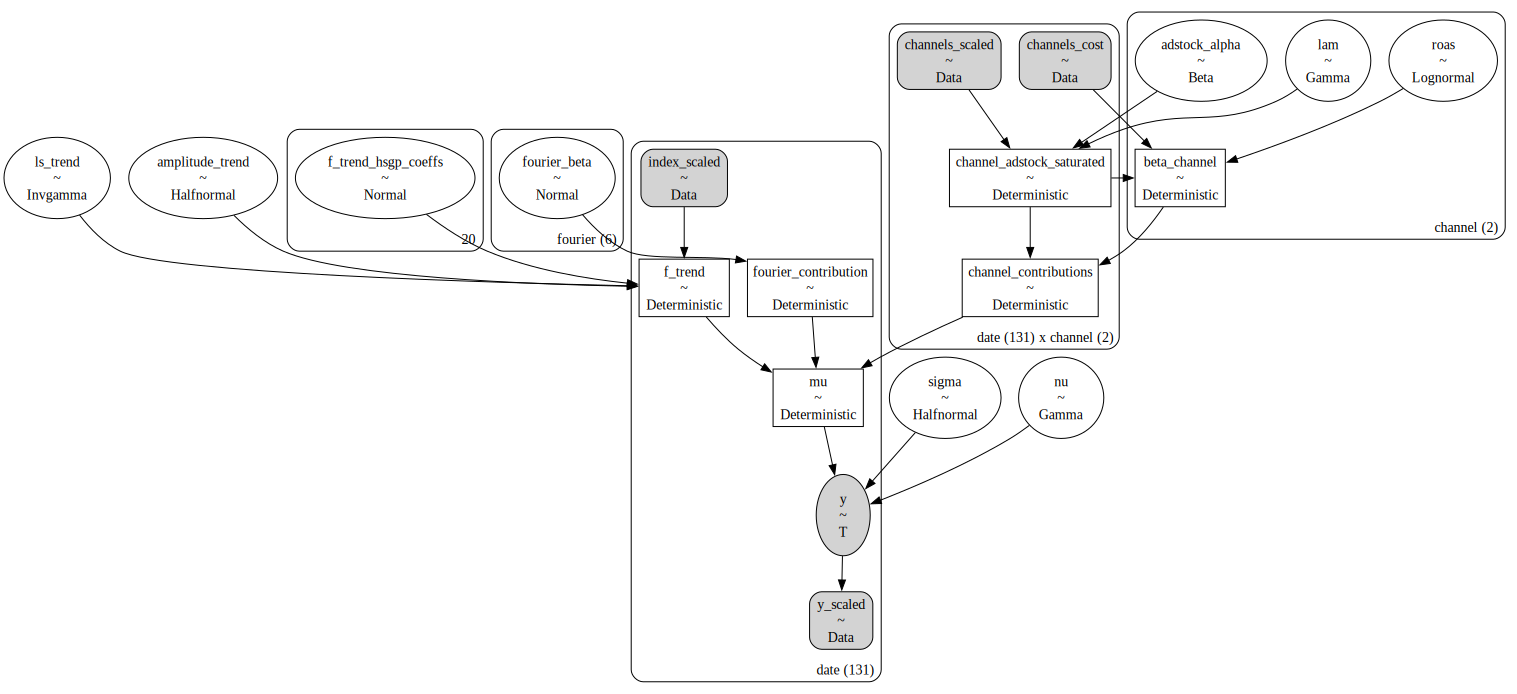

In [19]:
channels_cost = DataArray(raw_df[channels].to_numpy(), dims=("date", "channel"))

eps = np.finfo(float).eps

with pm.Model(coords=coords) as model_calibrated:
    # --- Data Containers ---
    index_data = pm.Data("index_scaled", index_scaled, dims="date")
    channels_data = pmd.Data(
        "channels_scaled", channels_scaled, dims=("date", "channel")
    )
    channels_cost_data = pmd.Data(
        "channels_cost", channels_cost, dims=("date", "channel")
    )
    y_data = pmd.Data("y_scaled", target_scaled, dims="date")

    # --- HSGP Trend ---
    amplitude_trend = pm.HalfNormal("amplitude_trend", sigma=1)

    ls_trend = pz.maxent(
        distribution=pz.InverseGamma(),
        lower=0.1,
        upper=0.9,
        mass=0.95,
        plot=False,
    ).to_pymc("ls_trend")

    cov_trend = amplitude_trend * pm.gp.cov.ExpQuad(input_dim=1, ls=ls_trend)
    gp_trend = pm.gp.HSGP(m=[20], c=1.5, cov_func=cov_trend)
    f_trend = gp_trend.prior("f_trend", X=index_data[:, None], dims="date")
    f_trend = ptx.as_xtensor(f_trend, dims=("date",))

    # --- Channel Effects (ROAS parameterization) ---
    lam = pmd.Gamma("lam", alpha=2, beta=2, dims="channel")
    roas = pmd.LogNormal(
        "roas", mu=np.log(roas_bar_scaled), sigma=error_scaled, dims="channel"
    )

    adstocked = adstock.apply(channels_data, core_dim="date")
    channel_adstock_saturated = pmd.Deterministic(
        "channel_adstock_saturated",
        logistic_saturation(adstocked, lam=lam),
        dims=("date", "channel"),
    )

    beta_channel = pmd.Deterministic(
        "beta_channel",
        (channels_cost_data.sum(dim="date") * roas)
        / (channel_adstock_saturated.sum(dim="date") + eps),
        dims="channel",
    )
    channel_contributions = pmd.Deterministic(
        "channel_contributions",
        channel_adstock_saturated * beta_channel,
        dims=("date", "channel"),
    )

    # --- Seasonality ---
    fourier_contribution = pmd.Deterministic(
        "fourier_contribution",
        yearly_fourier.apply(dayofyear),
        dims="date",
    )

    # --- Mean ---
    mu = pmd.Deterministic(
        "mu",
        f_trend + channel_contributions.sum(dim="channel") + fourier_contribution,
        dims="date",
    )

    # --- Likelihood ---
    sigma = pm.HalfNormal("sigma", sigma=1)
    nu = pm.Gamma("nu", alpha=25, beta=2)
    pmd.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y_data, dims="date")

pm.model_to_graphviz(model_calibrated)

### Fit Model

In [20]:
with model_calibrated:
    idata_calibrated = pm.sample(
        target_accept=0.95,
        draws=1_000,
        chains=4,
        nuts_sampler="nutpie",
        random_seed=rng,
    )
    posterior_predictive_calibrated = pm.sample_posterior_predictive(
        trace=idata_calibrated, random_seed=rng
    )

NUTS[nutpie]: [amplitude_trend, ls_trend, f_trend_hsgp_coeffs, lam, roas, adstock_alpha, fourier_beta, sigma, nu]


Output()

Sampling: [y]


Output()

We do not see any divergences.

### Channel Contributions vs True Effects

As before, we scale back the estimated channel contributions to the original data.

In [21]:
pp_mu_calibrated = xr.apply_ufunc(
    target_scaler.inverse_transform,
    idata_calibrated["posterior"]["mu"].expand_dims(dim={"_": 1}, axis=-1),
    input_core_dims=[["date", "_"]],
    output_core_dims=[["date", "_"]],
    vectorize=True,
).squeeze(dim="_")

pp_contributions_calibrated = xr.apply_ufunc(
    target_scaler.inverse_transform,
    idata_calibrated["posterior"]["channel_contributions"],
    input_core_dims=[["date", "channel"]],
    output_core_dims=[["date", "channel"]],
    vectorize=True,
)

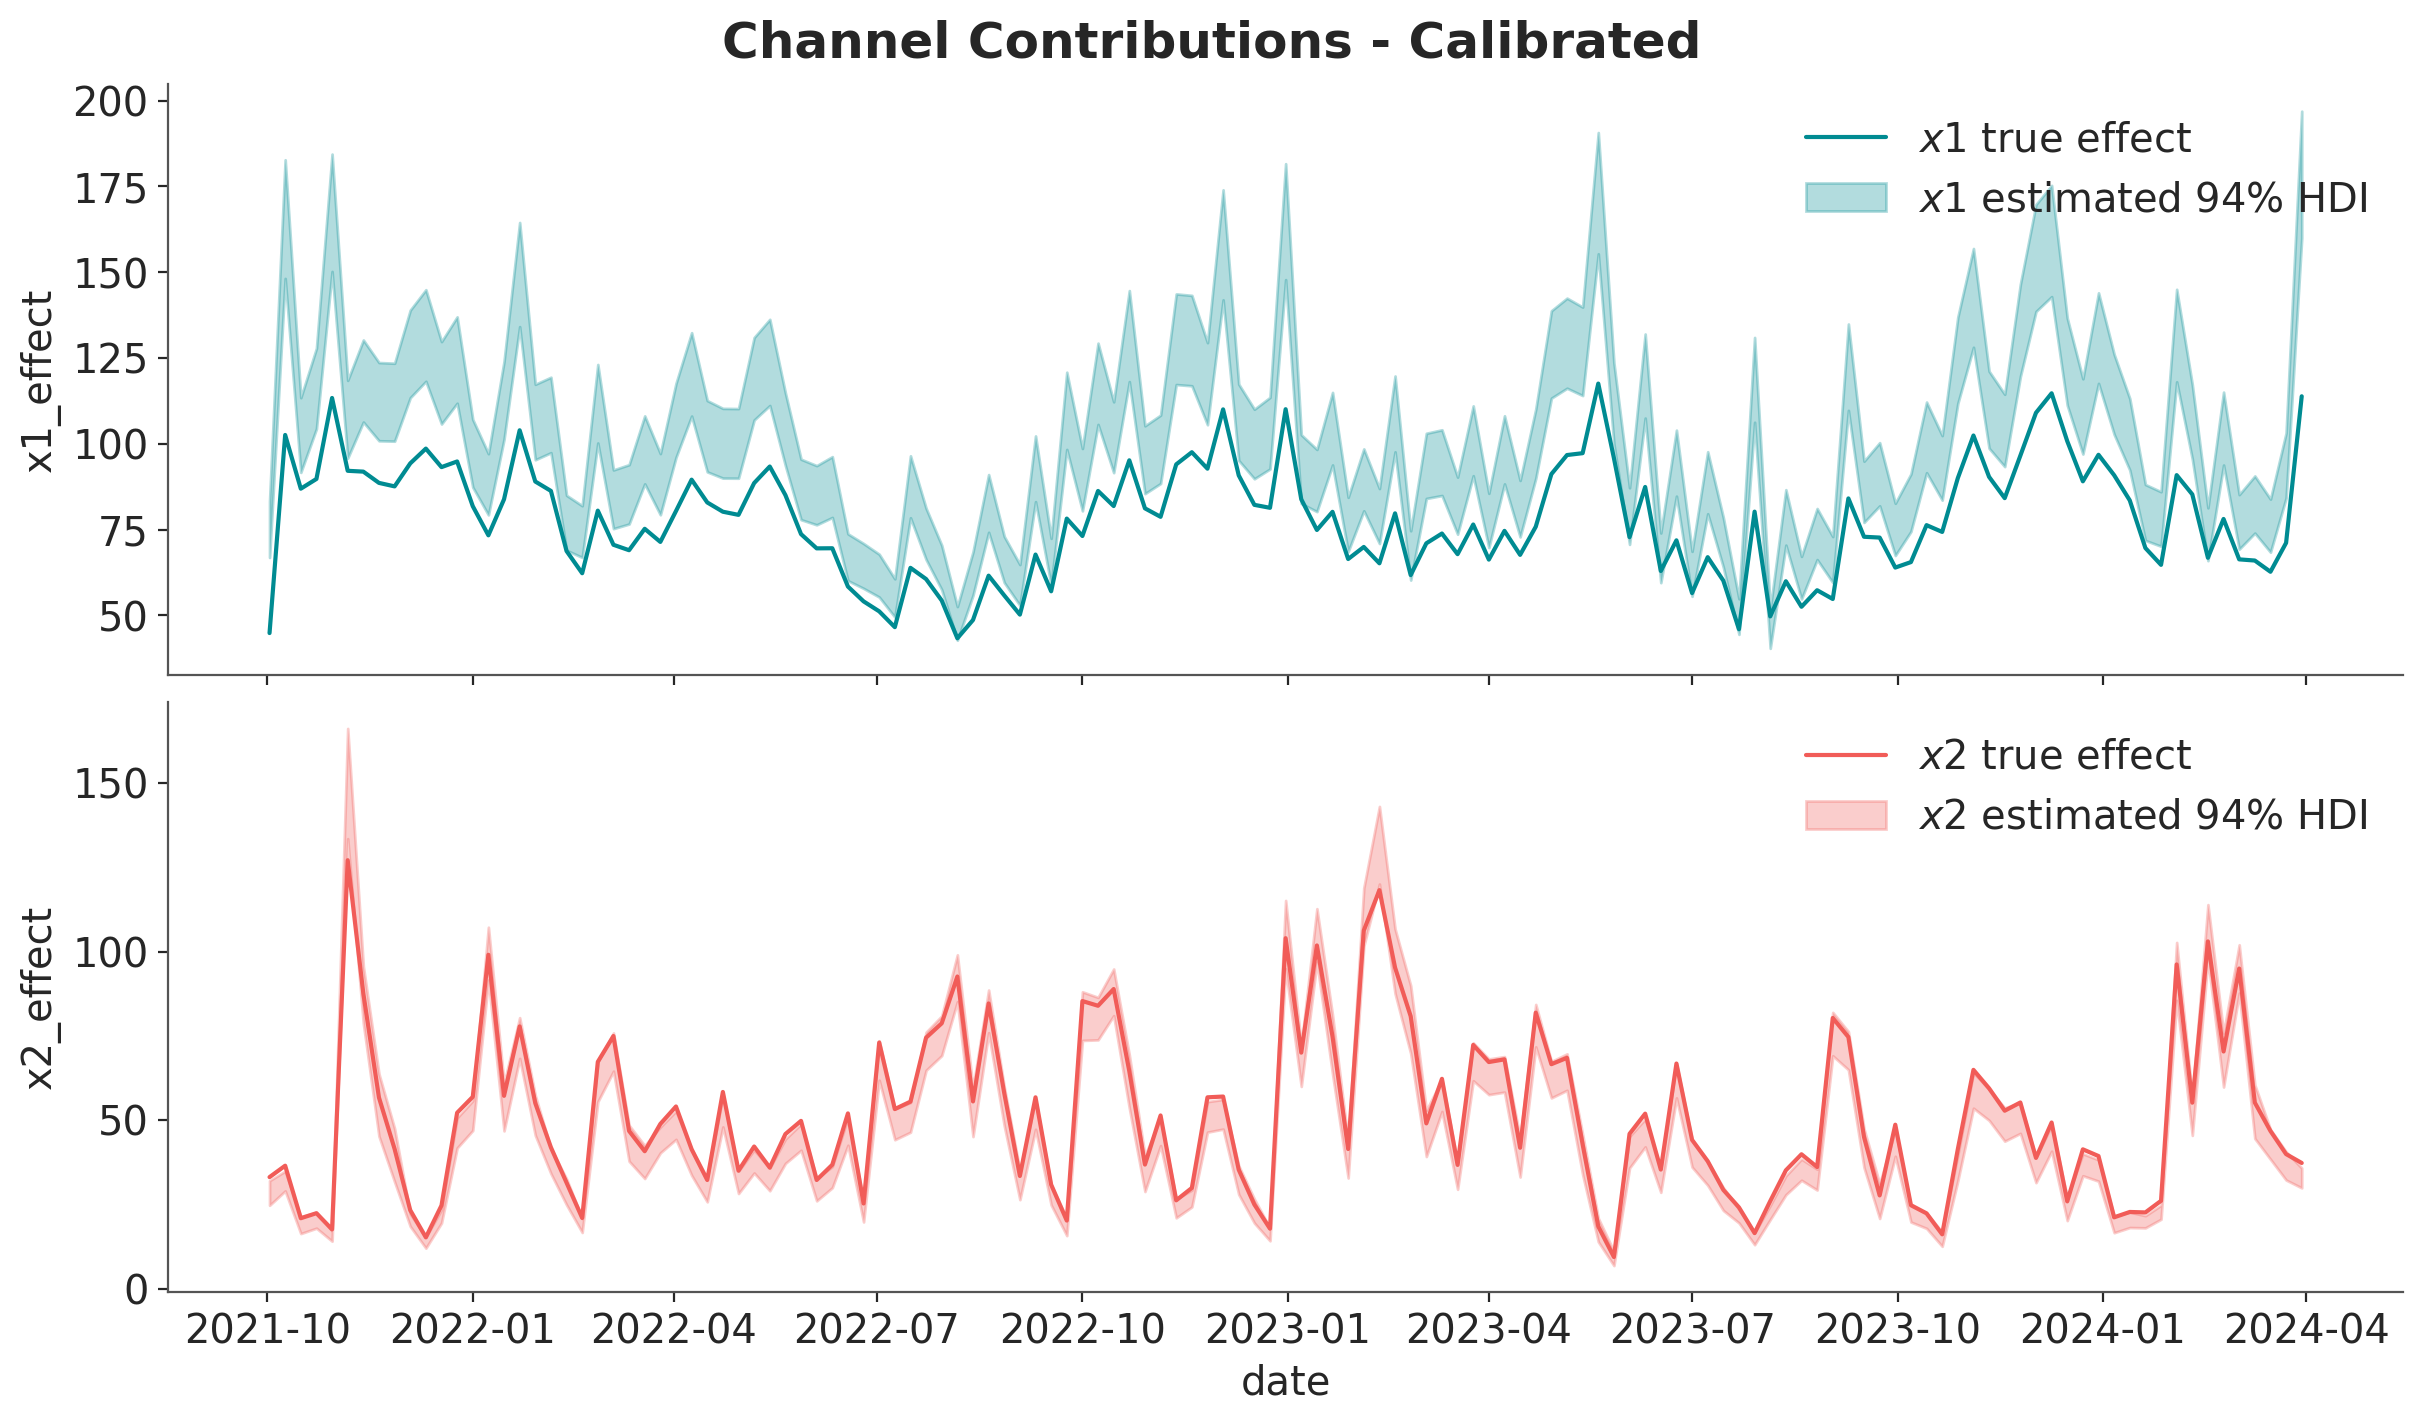

In [22]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 7), sharex=True, layout="constrained"
)
for i, ch in enumerate(channels):
    sns.lineplot(
        x="date",
        y=f"{ch}_effect",
        data=raw_df.assign(
            **{f"{ch}_effect": lambda df, c=ch: amplitude * df[f"{c}_effect"]}
        ),
        color=f"C{i}",
        label=rf"${ch}$ true effect",
        ax=ax[i],
    )
    hdi = az.hdi(pp_contributions_calibrated.sel(channel=ch), prob=0.94)
    ax[i].fill_between(
        date,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color=f"C{i}",
        alpha=0.3,
        label=rf"${ch}$ estimated $94\%$ HDI",
    )
    ax[i].legend(loc="upper right")
fig.suptitle("Channel Contributions - Calibrated", fontsize=18, fontweight="bold");

The results are much better! The contributions are much closer to the true effects. It is not perfect for $x_1$, but it is much better than before. This can translate into better decisions and downstream optimization.

### ROAS Estimation (Calibrated)

For the calibrated model, as before, we generate counterfactual predictions by zeroing out both `channels_scaled` (the model input) and `channels_cost`.

In [23]:
predictions_roas_calibrated = {}

for channel in channels:
    with model_calibrated:
        pm.set_data(
            new_data={
                "channels_scaled": channels_scaler.transform(
                    raw_df[channels].assign(**{channel: 0})
                ),
                "channels_cost": raw_df[channels].assign(**{channel: 0}).to_numpy(),
            }
        )
        preds = pm.sample_posterior_predictive(
            trace=idata_calibrated,
            var_names=["mu"],
            progressbar=False,
            random_seed=rng,
        )

    mu_counterfactual = xr.apply_ufunc(
        target_scaler.inverse_transform,
        preds["posterior_predictive"]["mu"].expand_dims(dim={"_": 1}, axis=-1),
        input_core_dims=[["date", "_"]],
        output_core_dims=[["date", "_"]],
        vectorize=True,
    ).squeeze(dim="_")

    diff = pp_mu_calibrated - mu_counterfactual
    predictions_roas_calibrated[channel] = diff.sum(dim="date") / raw_df[channel].sum()

Sampling: []


Sampling: []


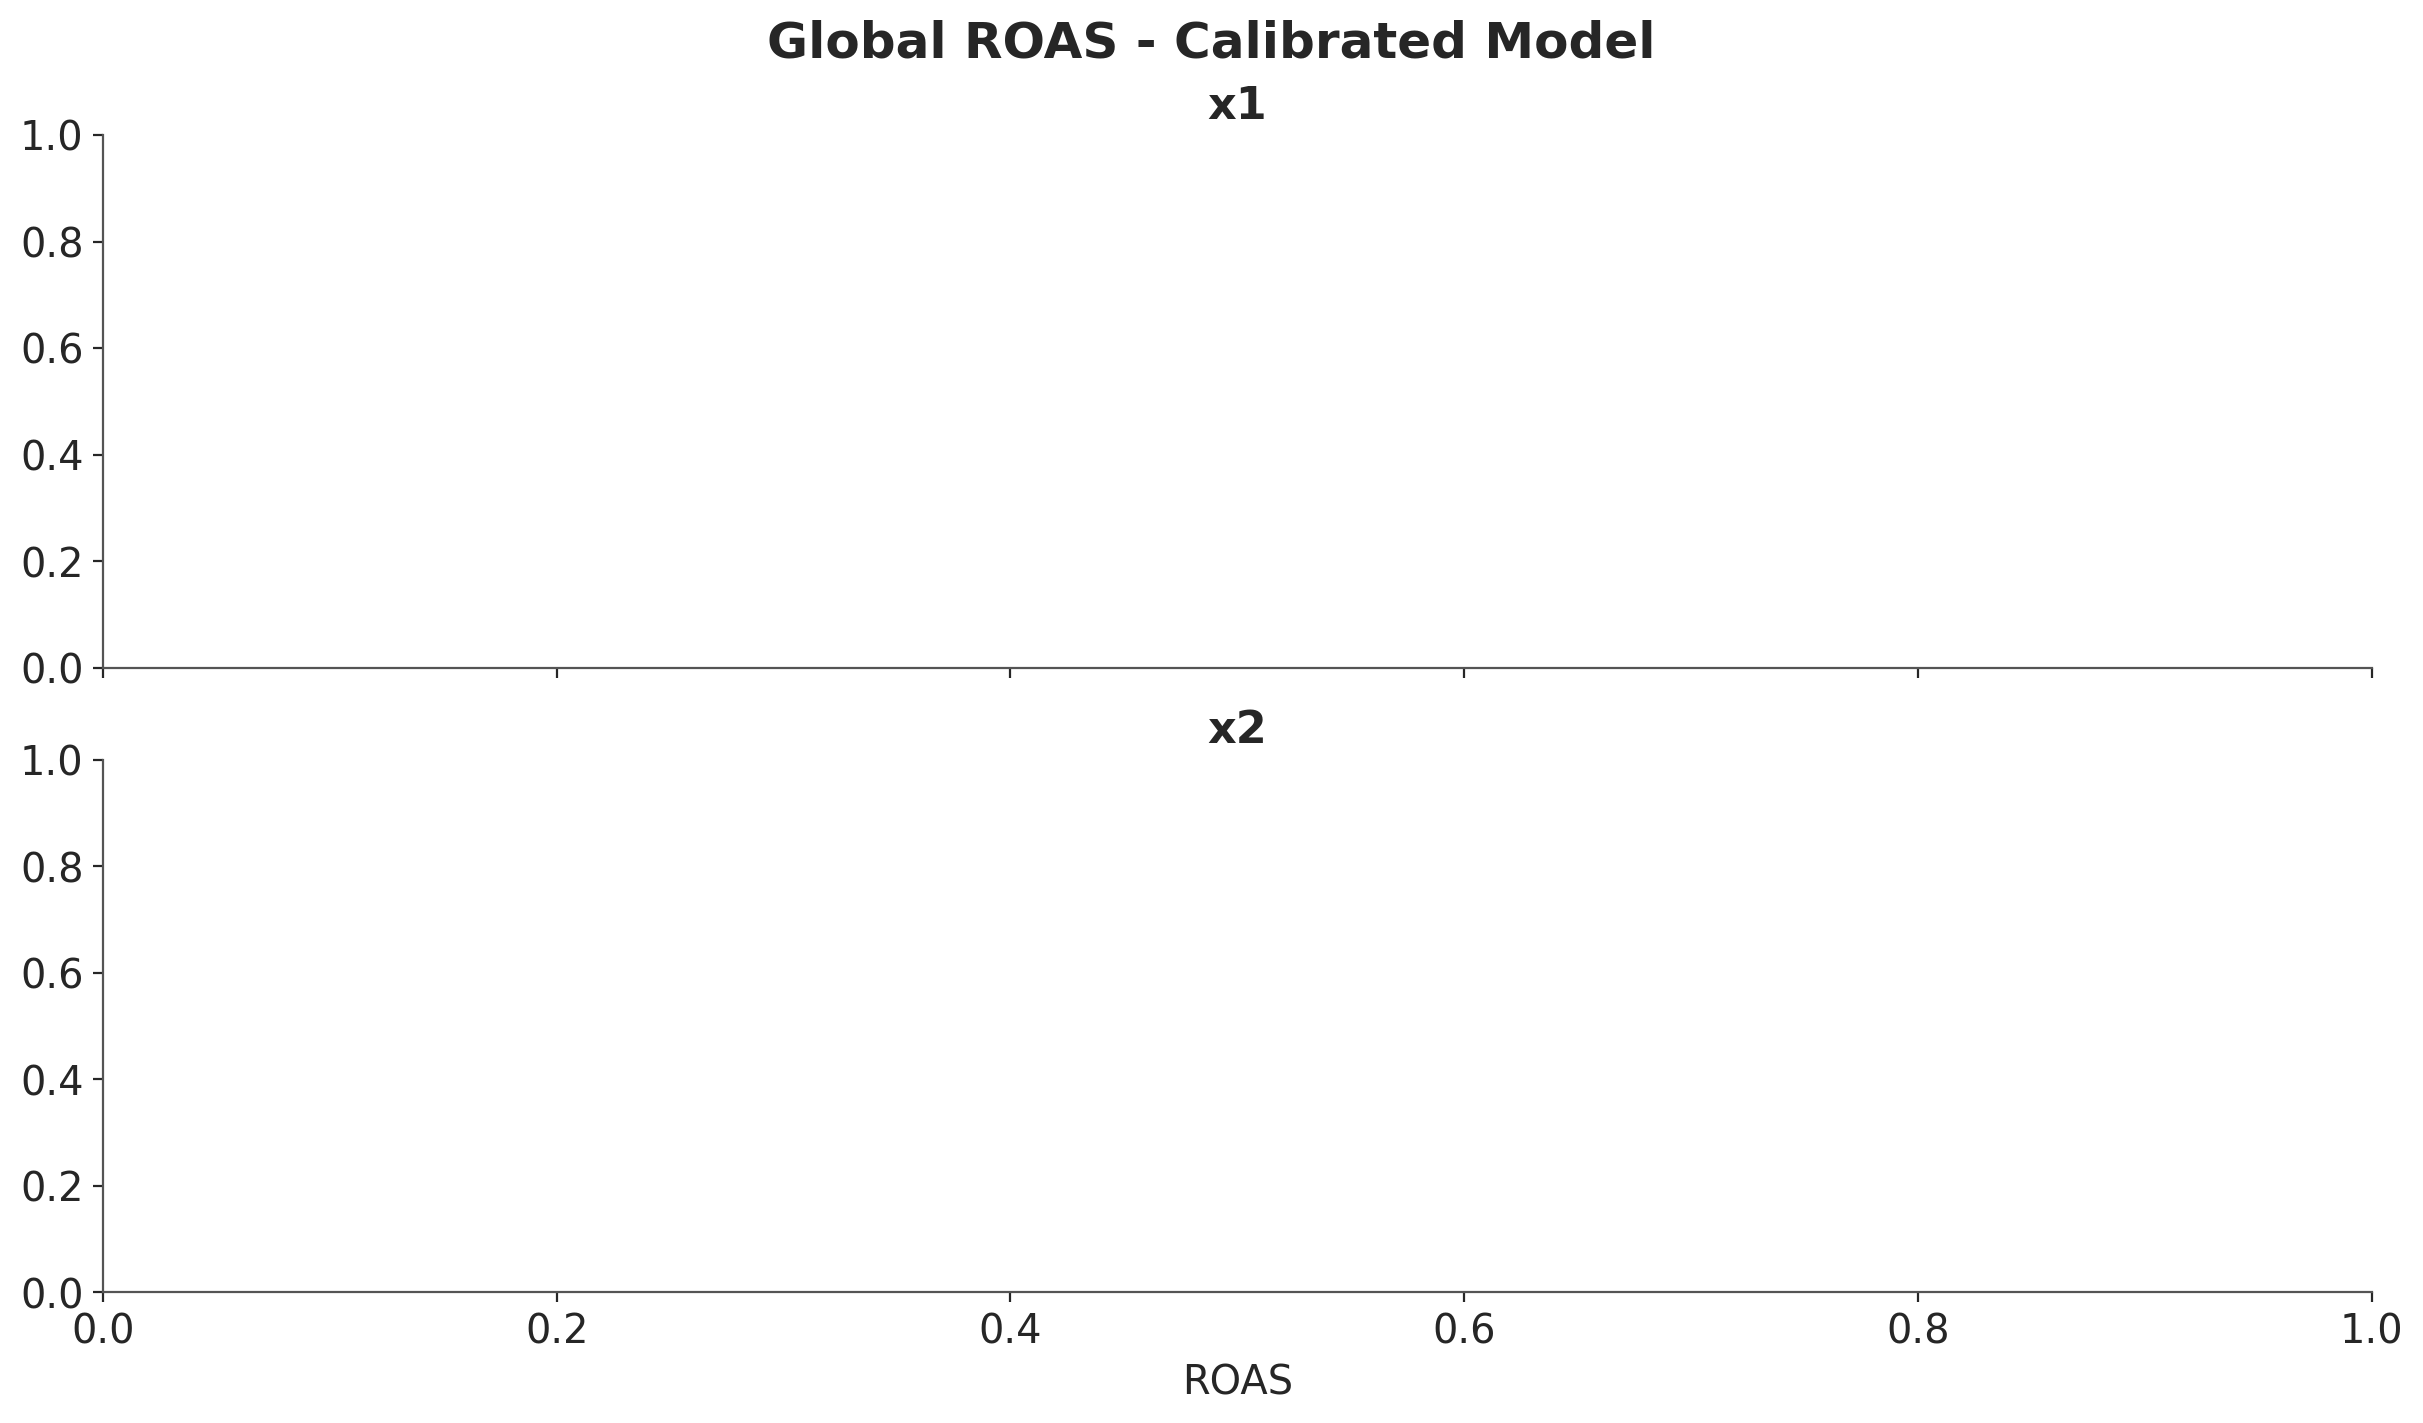

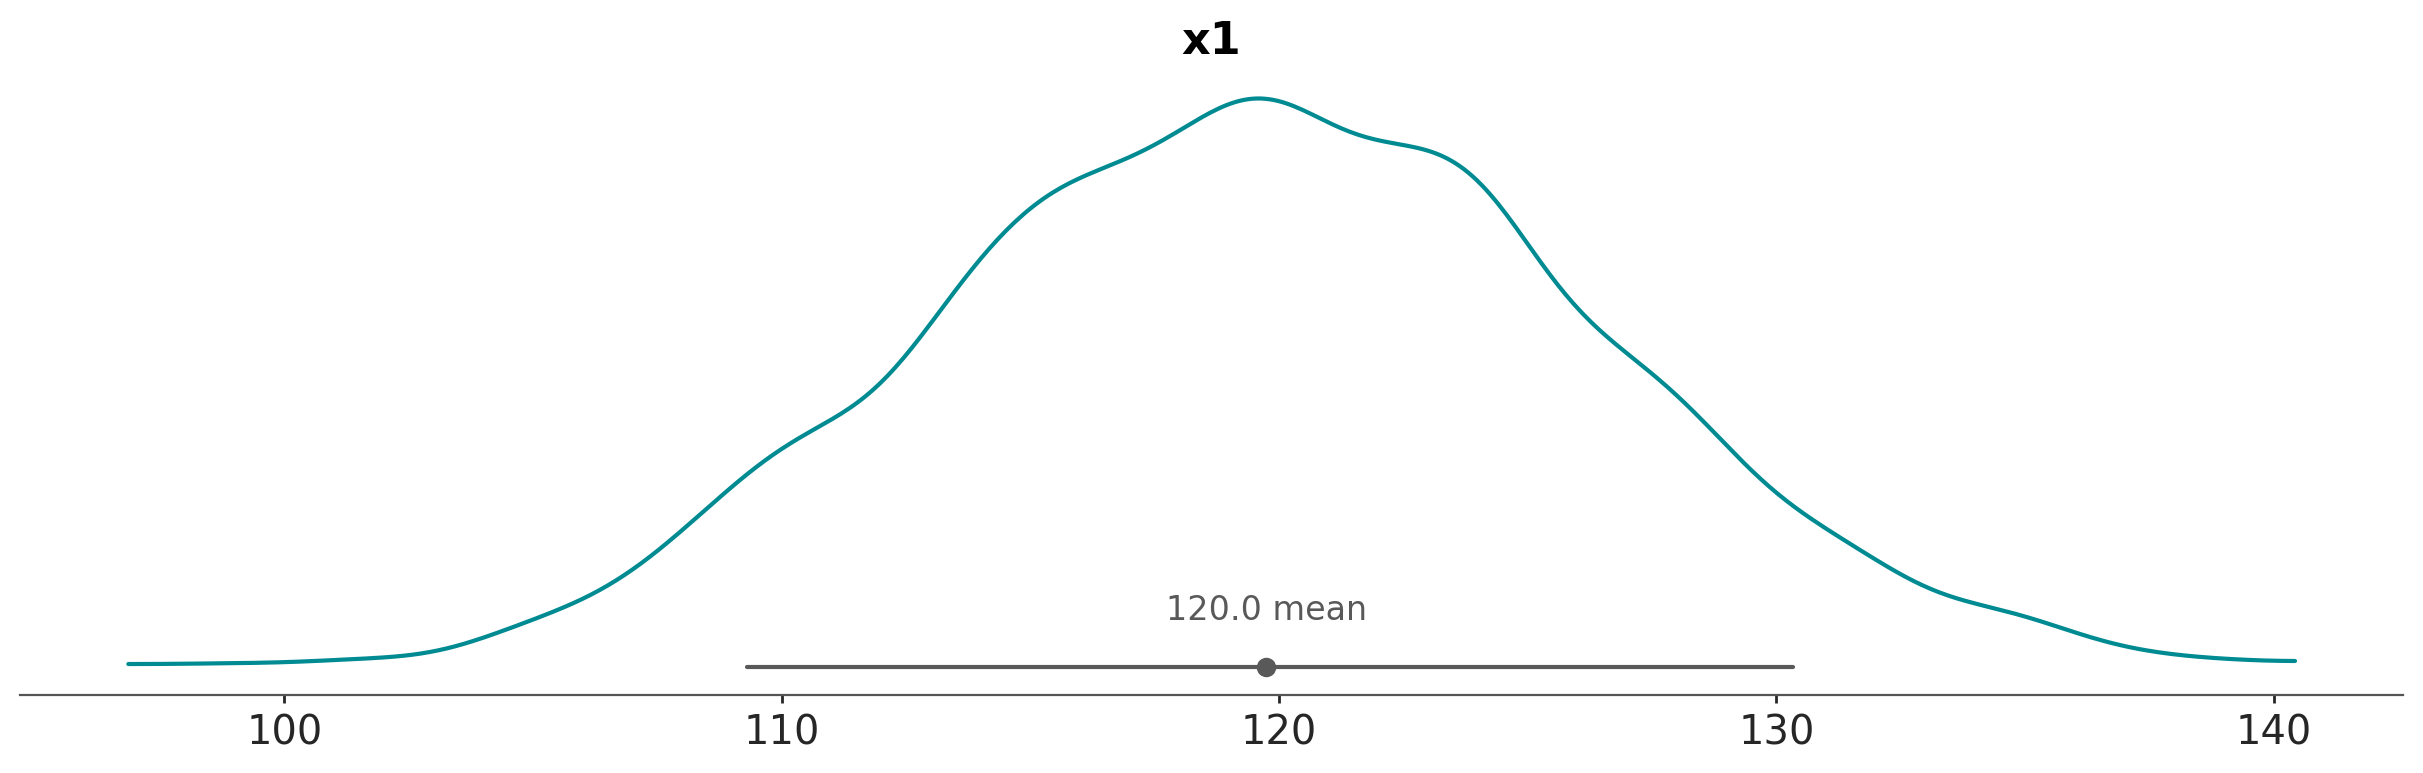

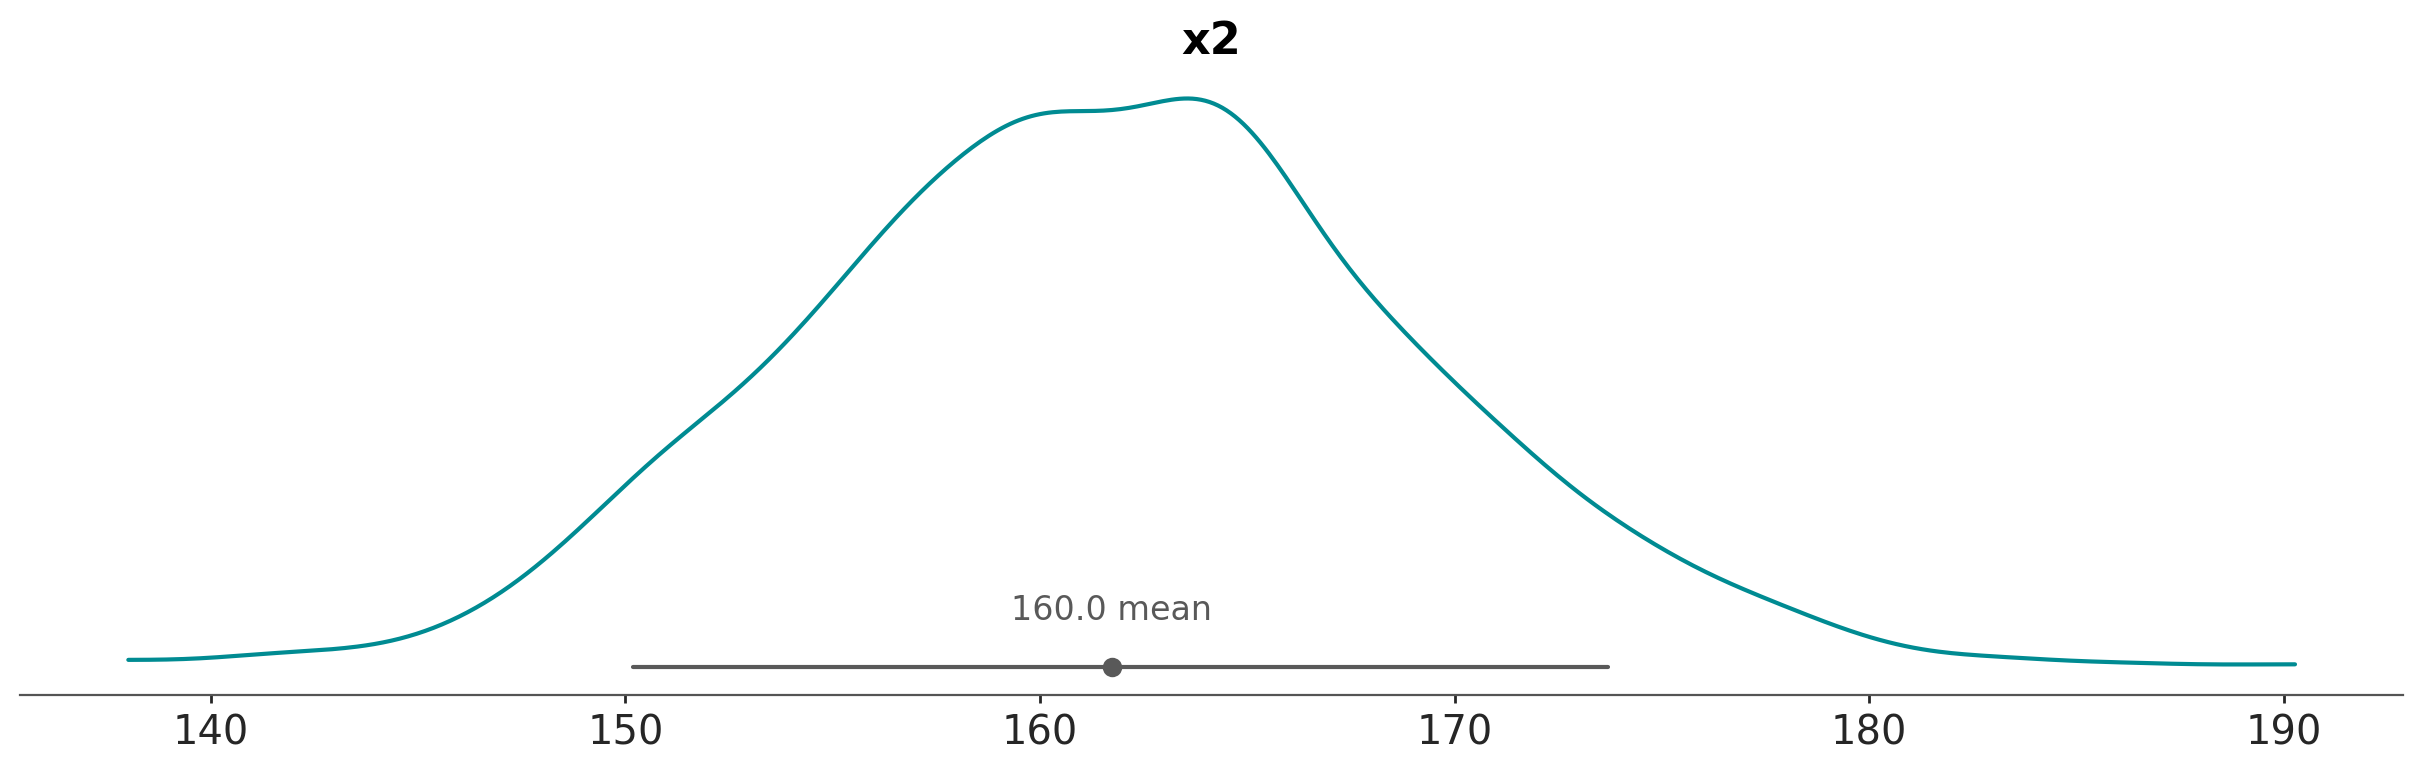

In [24]:
fig, ax = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 7), sharex=True, layout="constrained"
)
azp.plot_dist(
    xr.Dataset({"x1": predictions_roas_calibrated["x1"]}), sample_dims=["sample"]
)
ax[0].set(title="x1")
azp.plot_dist(
    xr.Dataset({"x2": predictions_roas_calibrated["x2"]}),
    sample_dims=["sample"],
)
ax[1].set(title="x2", xlabel="ROAS")
fig.suptitle("Global ROAS - Calibrated Model", fontsize=18, fontweight="bold");

The ROAS estimates are now closer to the true values, especially for $x_1$ where the confounding bias was most severe. Directionally, these estimates are much better for decision-making.

## Model Comparison

Let's summarize the results in a single figure.

ValueError: Keyword arguments ['model_names', 'ax'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

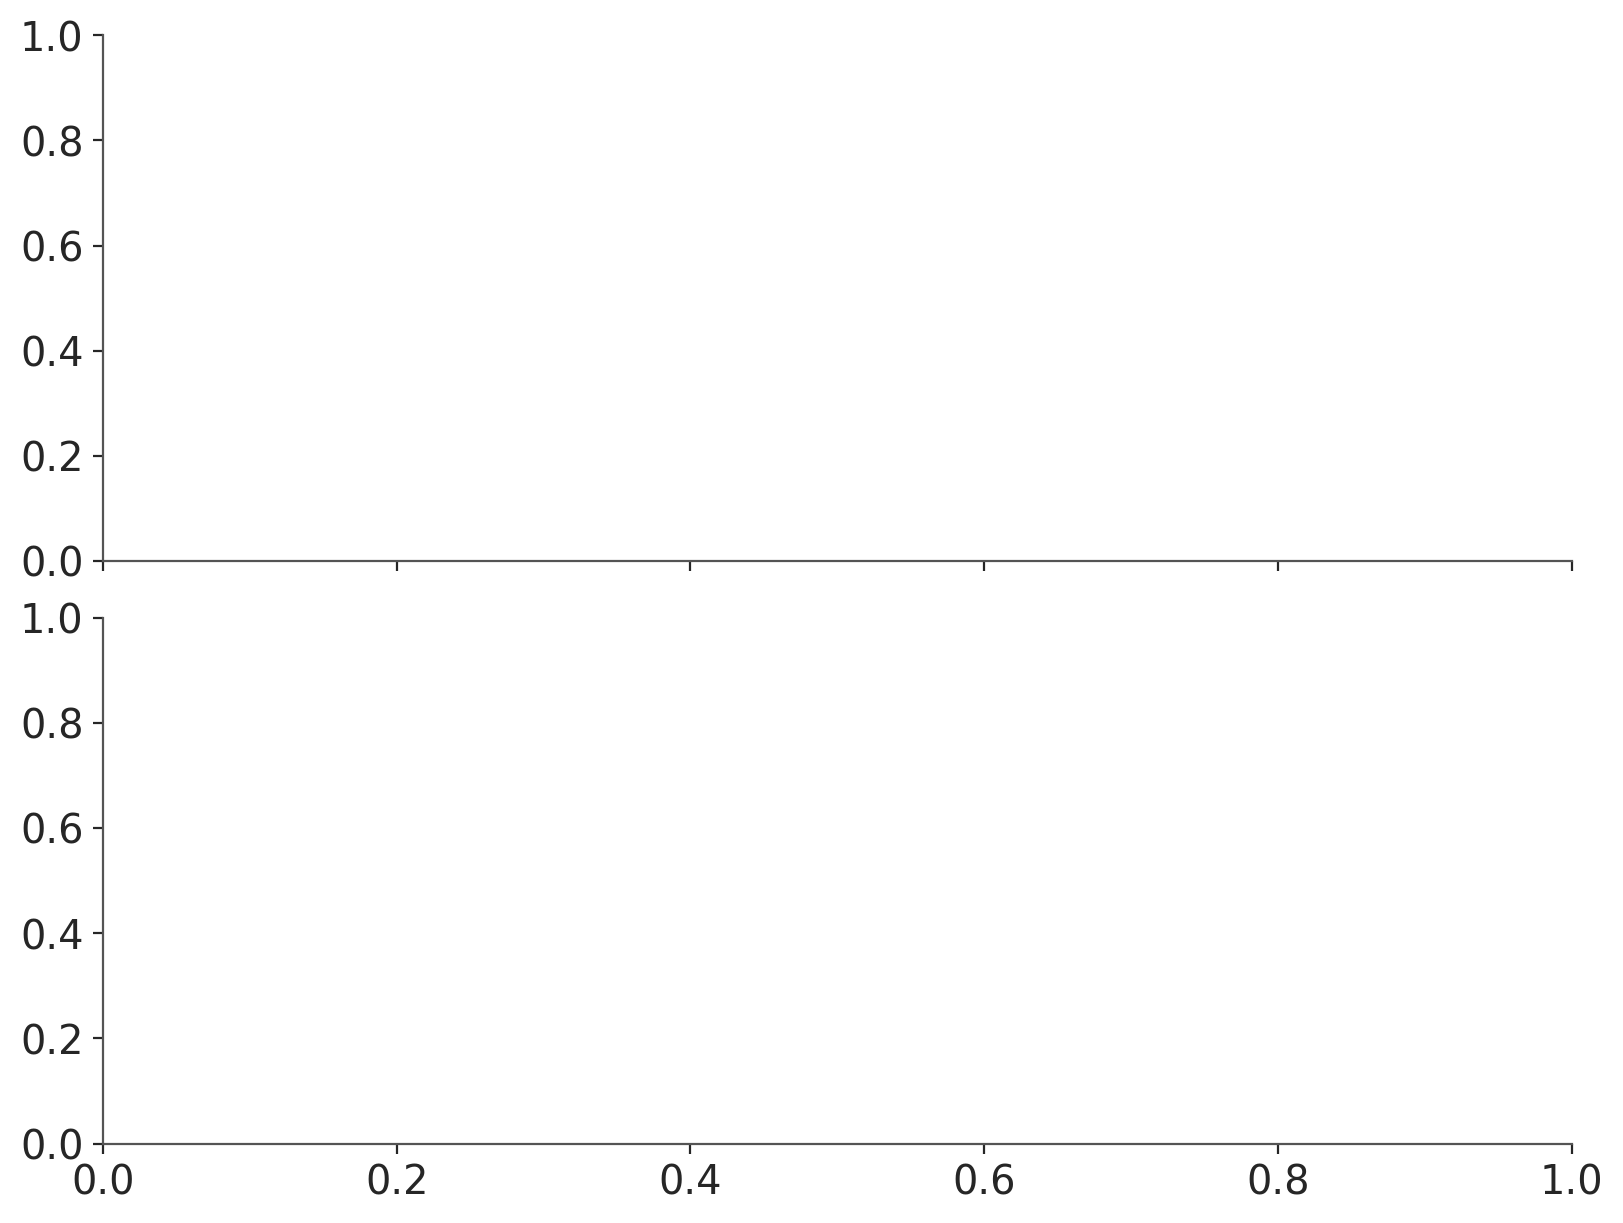

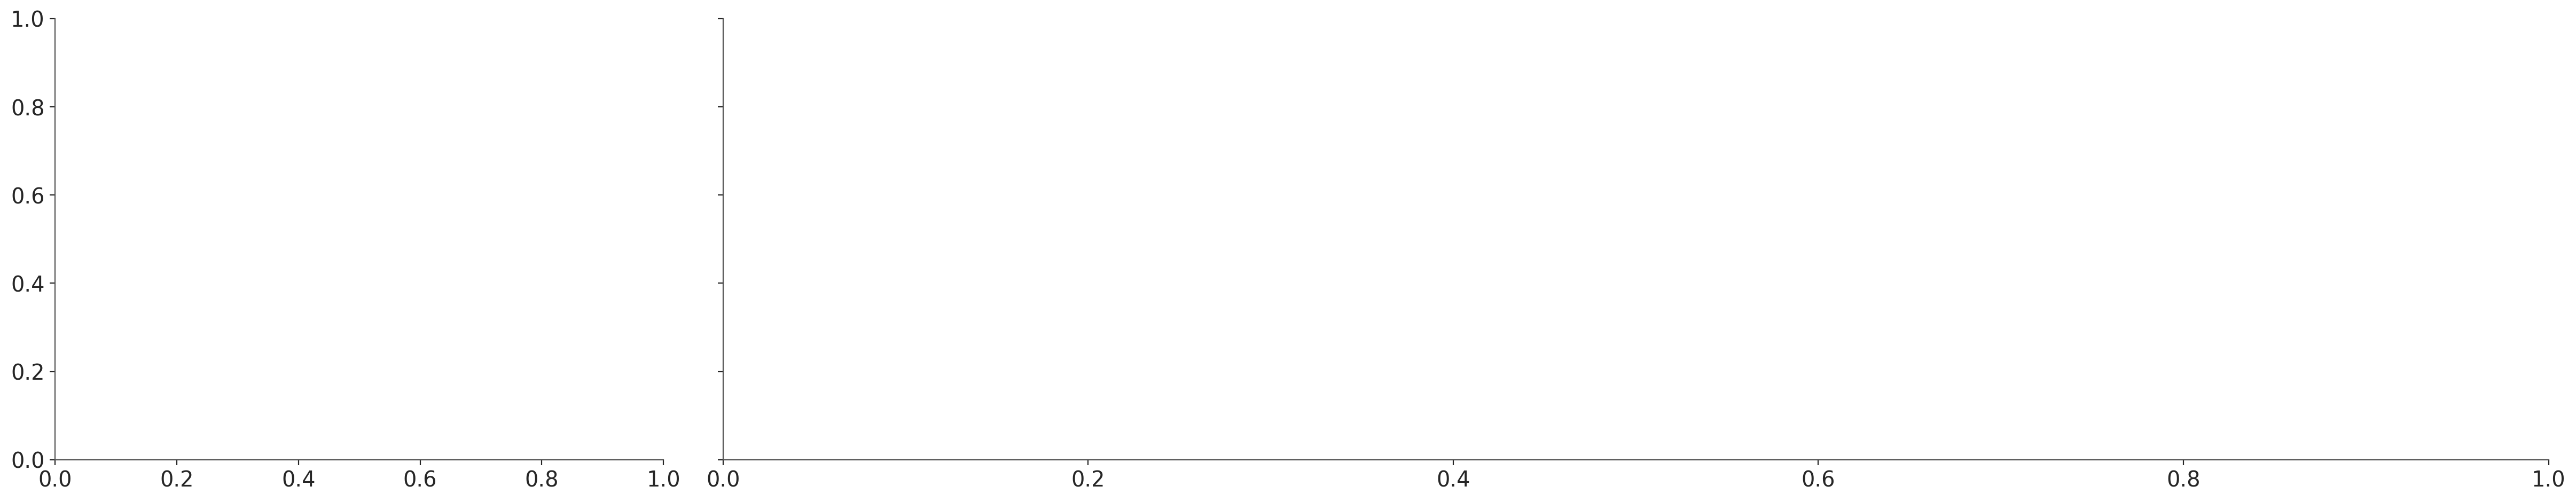

In [25]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 6),
    sharex=True,
    layout="constrained",
)

ds1 = xr.Dataset({"roas": predictions_roas_baseline["x1"]})
ds2 = xr.Dataset({"roas": predictions_roas_calibrated["x1"]})
azp.plot_forest(
    xr.concat([ds1, ds2], dim="model"),
    model_names=["Baseline", "Calibrated (ROAS prior)"],
    combined=True,
    ax=ax[0],
)
ax[0].axvline(
    x=roas_true_x1,
    color="black",
    linestyle="--",
    linewidth=2,
    label="True",
)
ax[0].text(
    roas_true_x1 + 1,
    0.5,
    "true value",
    rotation=90,
    color="black",
    fontsize=12,
    fontweight="bold",
    va="center",
    ha="left",
    transform=ax[0].get_xaxis_transform(),
)
ax[0].set(title="x1")

ds1 = xr.Dataset({"roas": predictions_roas_baseline["x2"]})
ds2 = xr.Dataset({"roas": predictions_roas_calibrated["x2"]})
azp.plot_forest(
    xr.concat([ds1, ds2], dim="model"),
    model_names=["Baseline", "Calibrated (ROAS prior)"],
    combined=True,
    ax=ax[1],
)
ax[1].axvline(x=roas_true_x2, color="black", linestyle="--", linewidth=2, label="True")
ax[1].text(
    roas_true_x2 + 1,
    0.5,
    "true value",
    rotation=90,
    color="black",
    fontsize=12,
    fontweight="bold",
    va="center",
    ha="left",
    transform=ax[1].get_xaxis_transform(),
)
ax[1].set(title="x2")

fig.suptitle("Global ROAS - Model Comparison", fontsize=18, fontweight="bold");

The comparison shows (as described above):

- **$x_1$**: The baseline model massively overestimates ROAS due to the confounding bias from $z$. The calibrated model, informed by the experimental ROAS prior, brings the estimate much closer to the true value.
- **$x_2$**: Both models produce reasonable estimates since $x_2$ has no confounding path, though the calibrated model provides tighter uncertainty bounds.

Note that the ROAS posteriors in the calibrated model are **not** identical to the priors; the likelihood (observed data) still influences the final estimates. The ROAS priors act as regularization, pulling the estimates toward experimentally validated values while still allowing the data to inform the posterior. This is where adding more experiments with **additional** likelihoods will help a lot (see {ref}`mmm_lift_test`).

In [26]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Tue, 09 Jun 2026

Python implementation: CPython
Python version       : 3.13.2
IPython version      : 9.14.0

arviz         : 1.1.0
arviz_plots   : 1.1.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
polars        : 1.41.2
preliz        : 0.25.0
pymc          : 6.0.1
pymc_extras   : 0.11.1.dev1+gd3254d131
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.4
seaborn       : 0.13.2
sklearn       : 1.9.0
xarray        : 2026.4.0

Watermark: 2.6.0

